In [2]:
import wandb
import pandas as pd 
import json
from tqdm import tqdm

import glob
from collections import defaultdict, OrderedDict
# from neurips import *
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import os
from termcolor import colored

import sys
sys.path.append("/mnt/home/focus")

plt.rcParams['figure.dpi'] = 600
file_format = 'numpy'
project_key = "dmc"

In [3]:
# Collect runs from different projects
# projects = {
#     "dmc" : ["offline_dreamer_dmc", "offline_skill_dreamer_dmc", "offline_lexa_dmc", "offline_skill_focus_dmc"],
#     "rs": ["offline_dreamer_rs", "offline_skill_dreamer_rs", "offline_lexa_rs", "offline_skill_focus_rs"],
#     "mw": ["offline_dreamer_mw", "offline_skill_dreamer_mw", "offline_lexa_mw", "offline_skill_focus_mw"],
# }

projects = {
    "dmc" : ["online_dreamer_dmc"],
}

from collections import defaultdict
import numpy as np
import json
import pandas as pd
from tqdm import tqdm
import os

target_metrics = ['move_to_target_min', 'move_to_target_max', 'move_to_target_mean', 'move_to_target_final', 'episode_reward', "reward_mean", "task_actor_loss", "critic"]

train_keys = [ 'train/' + k for k in target_metrics ]

eval_keys = []

config_keys = ['task', 'comment', 'seed', 'agent|distance_mode', 'expl_dataset', 'vis_target_dataset', "env|target_ablation_diam"]
    
all_keys = ['agent'] + config_keys + eval_keys + train_keys # 1 for agent and 1 for eval_reward
    

def load_and_save(runs, project_key, save_format='numpy', only_finished=True, comment_filter=None):
    new_runs = []
    runs_collected = 0
    if only_finished:
        for run in runs:
            if run.state == 'finished':
                new_runs.append(run)
    else:
        new_runs = runs

    summary = defaultdict(list)
    loaded = len(summary['task'])

    for run in tqdm(new_runs): 
        
        # .summary contains the output keys/values for metrics like accuracy.
        #  We call ._json_dict to omit large files 
        if save_format == 'numpy':
            try:
                # Remove any unfinished
                if os.path.isfile(f'projects_numpy/{project_key}/{run.id}_unfinished.npy'):
                    os.remove(f'projects_numpy/{project_key}/{run.id}_unfinished.npy')
                              
                load_keys = list(np.load(f'projects_numpy/{project_key}/{run.id}.npy', allow_pickle=True).item().keys())
                if len(load_keys) == len(all_keys):
#                     print("Found")
                    runs_collected += 1
                    continue
            except FileNotFoundError:
                pass
        
        
        null_runs = ["4d25xp6v", "ohhqewnv", "10r2gh92", "ldn4oqbb", "6xqdy3pt", "vdq7j5bc", "cgeuttz2"]
        # for null run the config file is not saved in the run object, a way to retrive is to load the config file that is saved in the run directory
        if run.id in null_runs:
            from pathlib import Path
            import yaml
            
            path = Path(run.metadata["program"]).parent / "exp_local"
            path = path / next(os.walk(path))[1][0]
            path = path / next(os.walk(path))[1][-1]
            config_path = path / ".hydra/config.yaml"
            overrides_path = path  / ".hydra/overrides.yaml"
            
            with open(config_path) as stream:
                config = yaml.safe_load(stream)
                run.config = config
            with open(overrides_path) as stream:
                overrides = yaml.safe_load(stream)
                run.config["comment"] = path.parts[5]
                run.config["agent"]["name"] = overrides[0].split("=")[1]
                run.config["task"] = overrides[-2].split("=")[1]
                run.config["expl_dataset"] = overrides[9].split("=")[1]
                run.config["vis_target_dataset"] = overrides[-1].split("=")[1]
                
        else:
            replace_dict = {"'": '"', 'True': 1, 'False': 0, "None": '"none"'}
            for k, v in replace_dict.items():
                run.config['agent'] = run.config['agent'].replace(k, str(v))
            
            replace_dict = {"'": '"', 'True': 1, 'False': 0, "None": 'none'}
            for k, v in replace_dict.items():
                run.config['env'] = run.config['env'].replace(k, str(v))
                
            run.config['agent'] = json.loads(run.config['agent'])
            run.config['env'] = json.loads(run.config['env'])
        
        if comment_filter is not None:
            if comment_filter not in run.config['comment']:
                continue
            
        runs_collected += 1
        agent_name = run.config['agent']['name']
        
        # alternatively to scan_history (very slow for large data) one can use history(samples=100000) to get all data
        
        train_history = list(run.scan_history(keys=train_keys))

        # Taking sum of train (exploration) metrics
        train_dict = {}
        for k in train_keys:
            train_dict[k] = [row[k] for row in train_history]
        
        eval_history = list(run.scan_history(keys=eval_keys))

        # Taking sum of eval task metrics
        eval_dict = {}
        for k in eval_keys:
            eval_dict[k] = [row[k] for row in eval_history]
            
        if save_format=='csv':
            summary['agent'].append(agent_name)
            for k in config_keys:
                summary[k].append(run.config[k])
            for k in train_keys:
                summary[k].append(sum(train_dict[k]))
            for k in eval_keys:
                summary[k].append(eval_dict[k][-1])
        elif save_format == 'numpy':
            archive = {}
            archive['agent'] = agent_name
            for k in config_keys:
                try:
                    v = run.config
                    for e in k.split("|"):
                        v = v[e]
                    archive[k] = v
                except:
                    archive[k] = None
            for k in train_keys:
                archive[k] = np.array(train_dict[k])
            for k in eval_keys:
                archive[k] = np.array(eval_dict[k])
            os.makedirs(f'projects_numpy/{project_key}', exist_ok=True)
            if only_finished:
                np.save(f'projects_numpy/{project_key}/{run.id}.npy', archive)
            else:
                np.save(f'projects_numpy/{project_key}/{run.id}_unfinished.npy', archive)
        
# TODO: rather than this better use npy files to save data, though they may be less handy to aggregate results
#       To save multiple values in a .csv
#         for i in range(len(eval_ret)):
#             summary[f'eval_ret_{i}'].append(eval_ret[i])
    
    if save_format == 'csv':
        runs_df = pd.DataFrame(summary)
        runs_df.to_csv(f'projects_csv/{project_key}.csv')
    print("Runs collected", runs_collected)

In [3]:
from tqdm import tqdm

api = wandb.Api(timeout=1000)
entity = "ferrarostefano"
comment_filter = "online_reacher_benchmark_1_vis_target_ablation"
for project in tqdm(projects[project_key]):  # set to your entity and project 
    runs = api.runs(entity + "/" + project) 
    load_and_save(runs, project, save_format='numpy', only_finished=False, comment_filter=comment_filter)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter, or press ctrl+c to quit:wandb: Appending key for api.wandb.ai to your netrc file: /tmp/.netrc
100%|██████████| 1/1 [00:42<00:00, 42.91s/it]

Runs collected 21


In [4]:

project_key = "dmc"
all_data = {}

for project in tqdm(projects[project_key]):  # set to your entity and project
    if file_format == 'numpy':
        all_data[project] = [] 
        for k in [project]:
            all_files = glob.glob(f'projects_numpy/{k}/*.npy')

            for filename in all_files:
                try:
                    data = np.load(filename, allow_pickle=True)
                except FileNotFoundError as e:
                    print(filename, "NOT FOUND")
                all_data[project].append(data)
        # for data_dict in all_data[project]:
            # data_dict.item()['task'] = data_dict.item()['task']
    else:
        li = []

        all_files = [ k + ".csv" for k in projects]

        for filename in all_files:
            try:
                df = pd.read_csv(f'projects_csv/{filename}', index_col=None, header=0)
                df.drop(df.columns[df.columns.str.contains('unnamed',case = False)],axis = 1, inplace = True)
                li.append(df)
            except FileNotFoundError as e:
                print(filename, "NOT FOUND")

        frame = pd.concat(li, axis=0, ignore_index=True)

100%|██████████| 1/1 [00:00<00:00, 103.61it/s]


In [5]:
from copy import deepcopy

metrics_keys = ["train/move_to_target_mean", "train/episode_reward", "train/reward_mean", "train/critic"]


metrics_title = OrderedDict({
    "train/move_to_target_mean": "Mean Score",
    "train/episode_reward": "Episode Reward", 
    "train/reward_mean": "Expected Reward",
    "train/critic": "Value Prediction",
    })

agent2label = OrderedDict({
    'dreamer' : 'Dreamer',
    'skill_dreamer' : 'Skill Dreamer',
    'dist_dreamer' : 'Dist Dreamer',
    'lexa_cosine' : 'LEXA cosine',
    'lexa_temporal' : 'LEXA temporal',
    'skill_focus': 'FOCUS ++',
})


diam2color = OrderedDict({
    '10'  : "#56B4E9",
    '8'  : "#F0E442",
    '6'  : "#E69F00",
    '4' : "#009E73",
    '2' : "#CC79A7",
    '1': "#D55E00",
    '0': "#0072B2",
})

# limit = 7984 if project_key == 'RSS_explore' else 3500

In [6]:
plt_data = defaultdict(lambda : defaultdict(list))

plotting = True
printing = True
time_limit = 199
task = "reacher_easy"
# Organize data
for k, data_dict in all_data.items():
    for data in data_dict:
            if task != data.item()["task"]:
                continue
            
            diam = data.item()["env|target_ablation_diam"]
            
            for k in metrics_keys:
                print(data.item()[k][:time_limit].shape)
                # if k == "eval/episode_reward" and agent == "dist_dreamer": # rewards needs to be adapted from distance based to the scale of the normal reward
                    # plt_data[task][agent][expl][vis_target][k].append((data.item()[k][:time_limit] + 120) * 1000/120)
                # else:
                plt_data[diam][k].append(data.item()[k][:time_limit])

# Aggregate data
for diam in plt_data:
    plt_data[diam][k] = np.stack(plt_data[diam][k], axis=0)


(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)
(199,)


In [15]:
print(metrics_keys)

['train/move_to_target_mean', 'train/episode_reward', 'train/reward_mean', 'train/critic']


Set train/move_to_target_mean - train/critic
4
0
1
10
8
6
2
Set train/move_to_target_mean - train/critic
4
0
1
10
8
6
2


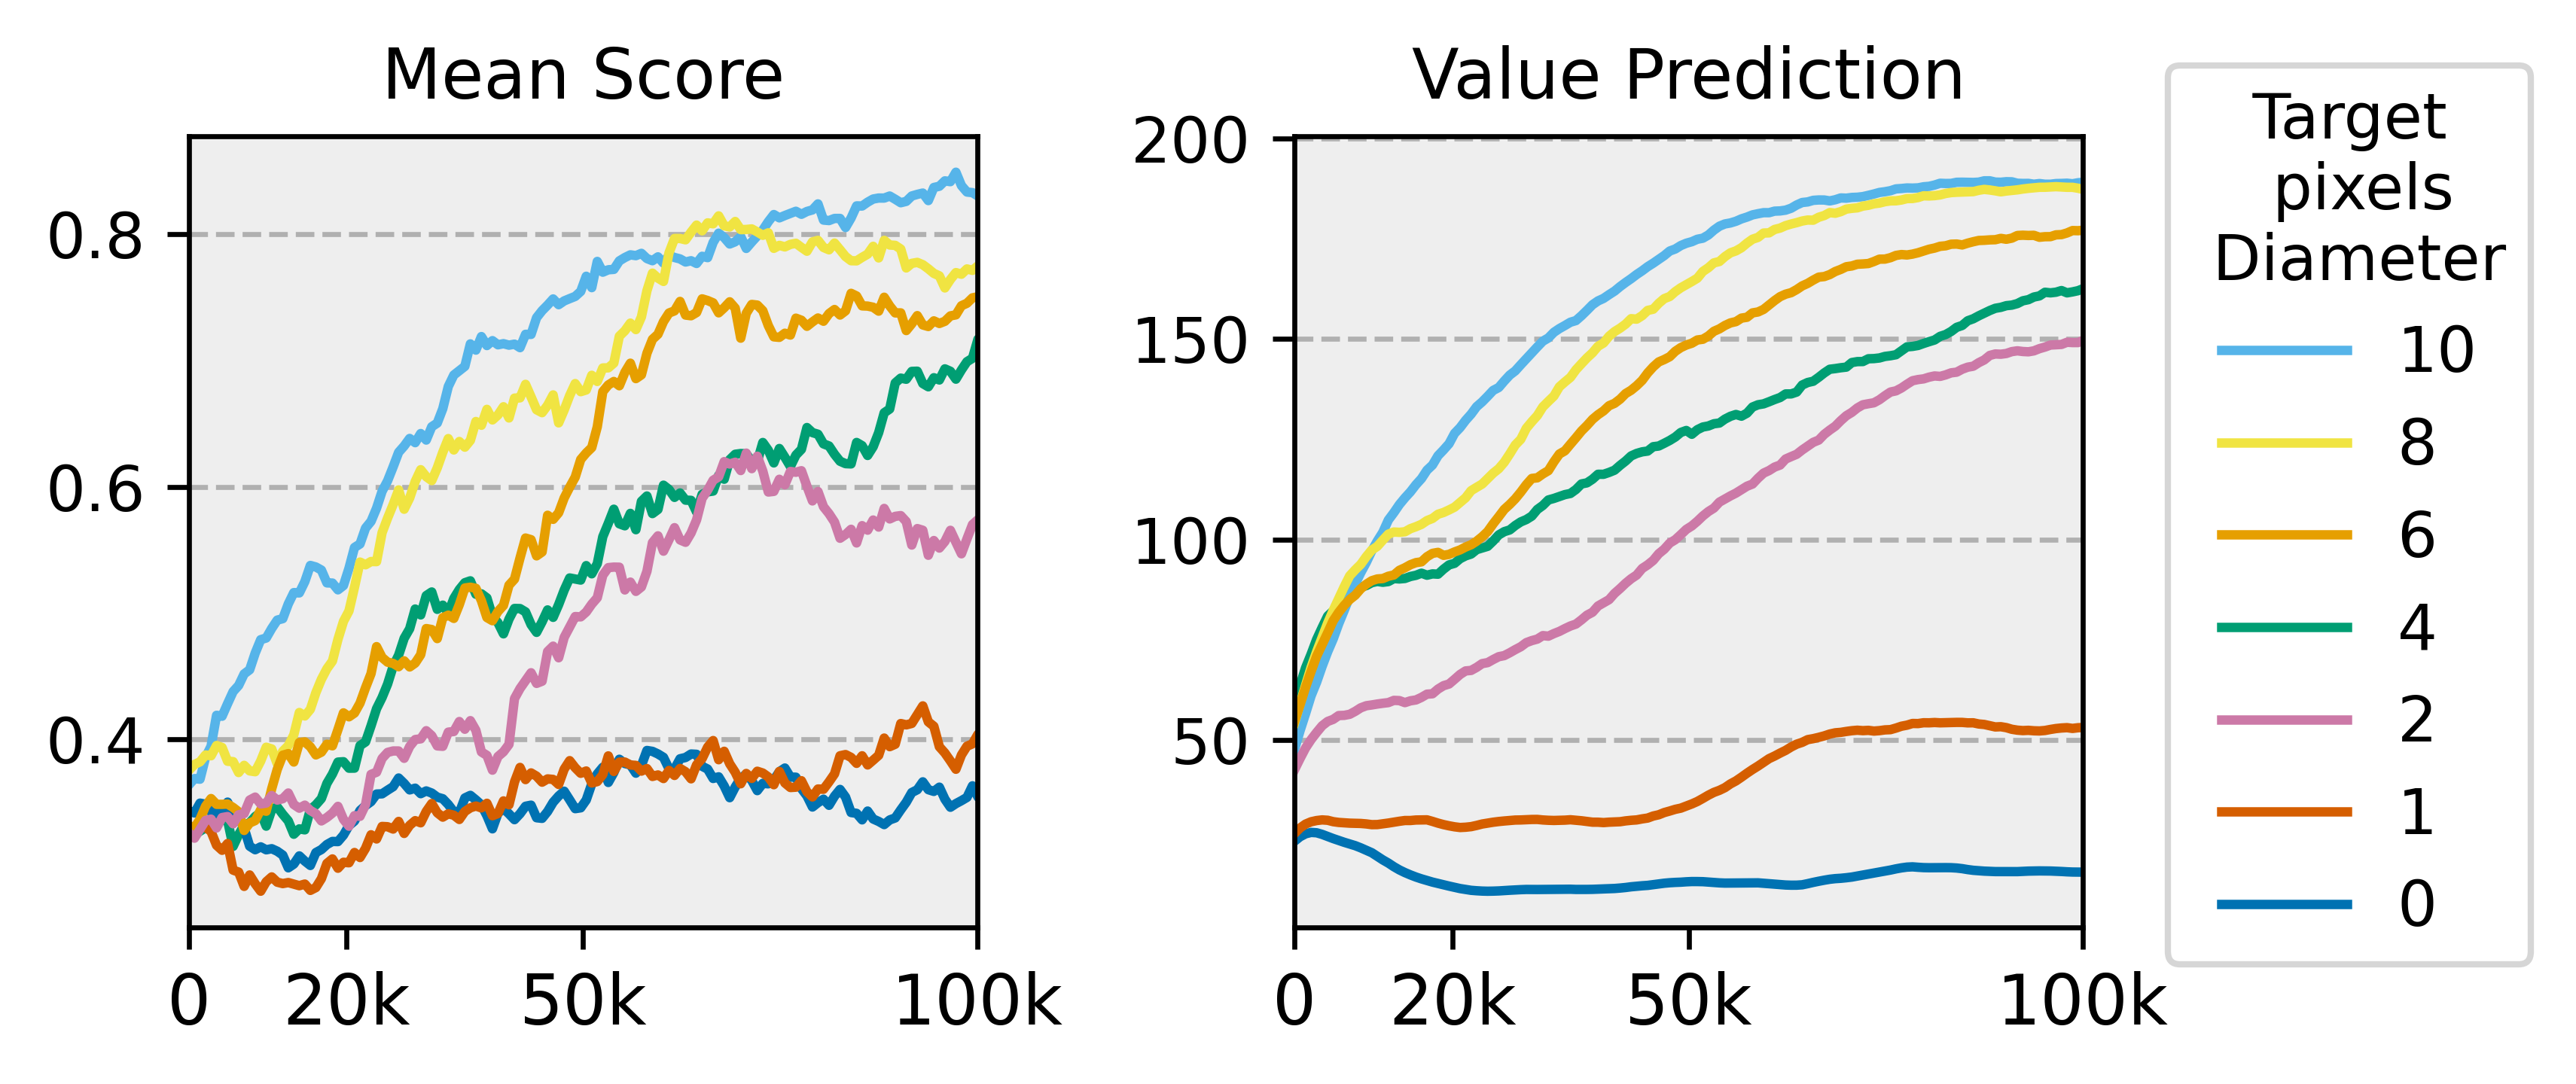

In [18]:
import itertools
from utils import colors

metrics_keys = ['train/move_to_target_mean', 'train/critic']
columns = metrics_keys
n_columns = len(columns)

if plotting:
    fig, rc_axes = plt.subplots(1, n_columns, figsize=(2.5 * n_columns,2.5))
    fig.set_facecolor('#ffffff')

max_handles, max_labels = [[],[]]
all_printing = {}

for i, param in enumerate(columns):
    if plotting:
        nl = '\n'
        rc_axes[i].set_title(f"{metrics_title[param]}", fontsize=11)
    if printing:
        print("Set", f"{columns[0]} - {columns[1]}")
    task_printing = {}
    
    # formatting of graph
    if plotting:
        ax = rc_axes[i]
        # if i == 0:
            # ax.set_ylabel(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=12)
        ax.set_facecolor('#eeeeee')
        ax.grid(visible=True, which='major', axis='y', linestyle='--',)
        ax.set_xlim(0, 5e5)
        ax.set_xticks([0,100e3, 250e3, 500e3])
        ax.set_xticklabels(['0','20k', '50k', '100k'], fontsize=11)
    
    for j, diam in enumerate(plt_data):
        print(diam)
        if plotting:
            y = plt_data[diam]
            x = np.array([i for i in range(len(y))])

            kernel_size = 20
            kernel = np.ones(kernel_size) / kernel_size
            convolved_y = np.stack([np.convolve(z, kernel, mode='valid') for z in plt_data[diam][param]])
            Y_Final = convolved_y.mean(axis=0)
            X_Final = np.array([i for i in range(len(Y_Final))]) * 3500
            label = f"{diam}"
            ax.plot(X_Final, Y_Final, label=label, color=diam2color[str(diam)])

            handles, labels = ax.get_legend_handles_labels()
            if len(handles) > len(max_handles):
                max_handles, max_labels = ax.get_legend_handles_labels()
                                         
    
if plotting:
    legend_elements = [plt.Line2D([0], [0], color=diam2color[str(diam)], label=diam) for j, diam in enumerate(diam2color.keys())]
    fig.legend(handles=legend_elements, loc='upper center', ncol=1, bbox_to_anchor=(1.05,0.95), title="   Target \n    pixels \n Diameter")

    # by_label = dict(zip(max_labels, max_handles))
    # fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=len(by_label), bbox_to_anchor=(0.5,1.01))
    plt.tight_layout()

    fig.savefig(f'target_ablation.png', facecolor=fig.get_facecolor(), bbox_inches='tight', format='png')

Set train/move_to_target_mean - train/critic
10
8
6
4
2
1
0
Set train/move_to_target_mean - train/critic
10
8
6
4
2
1
0


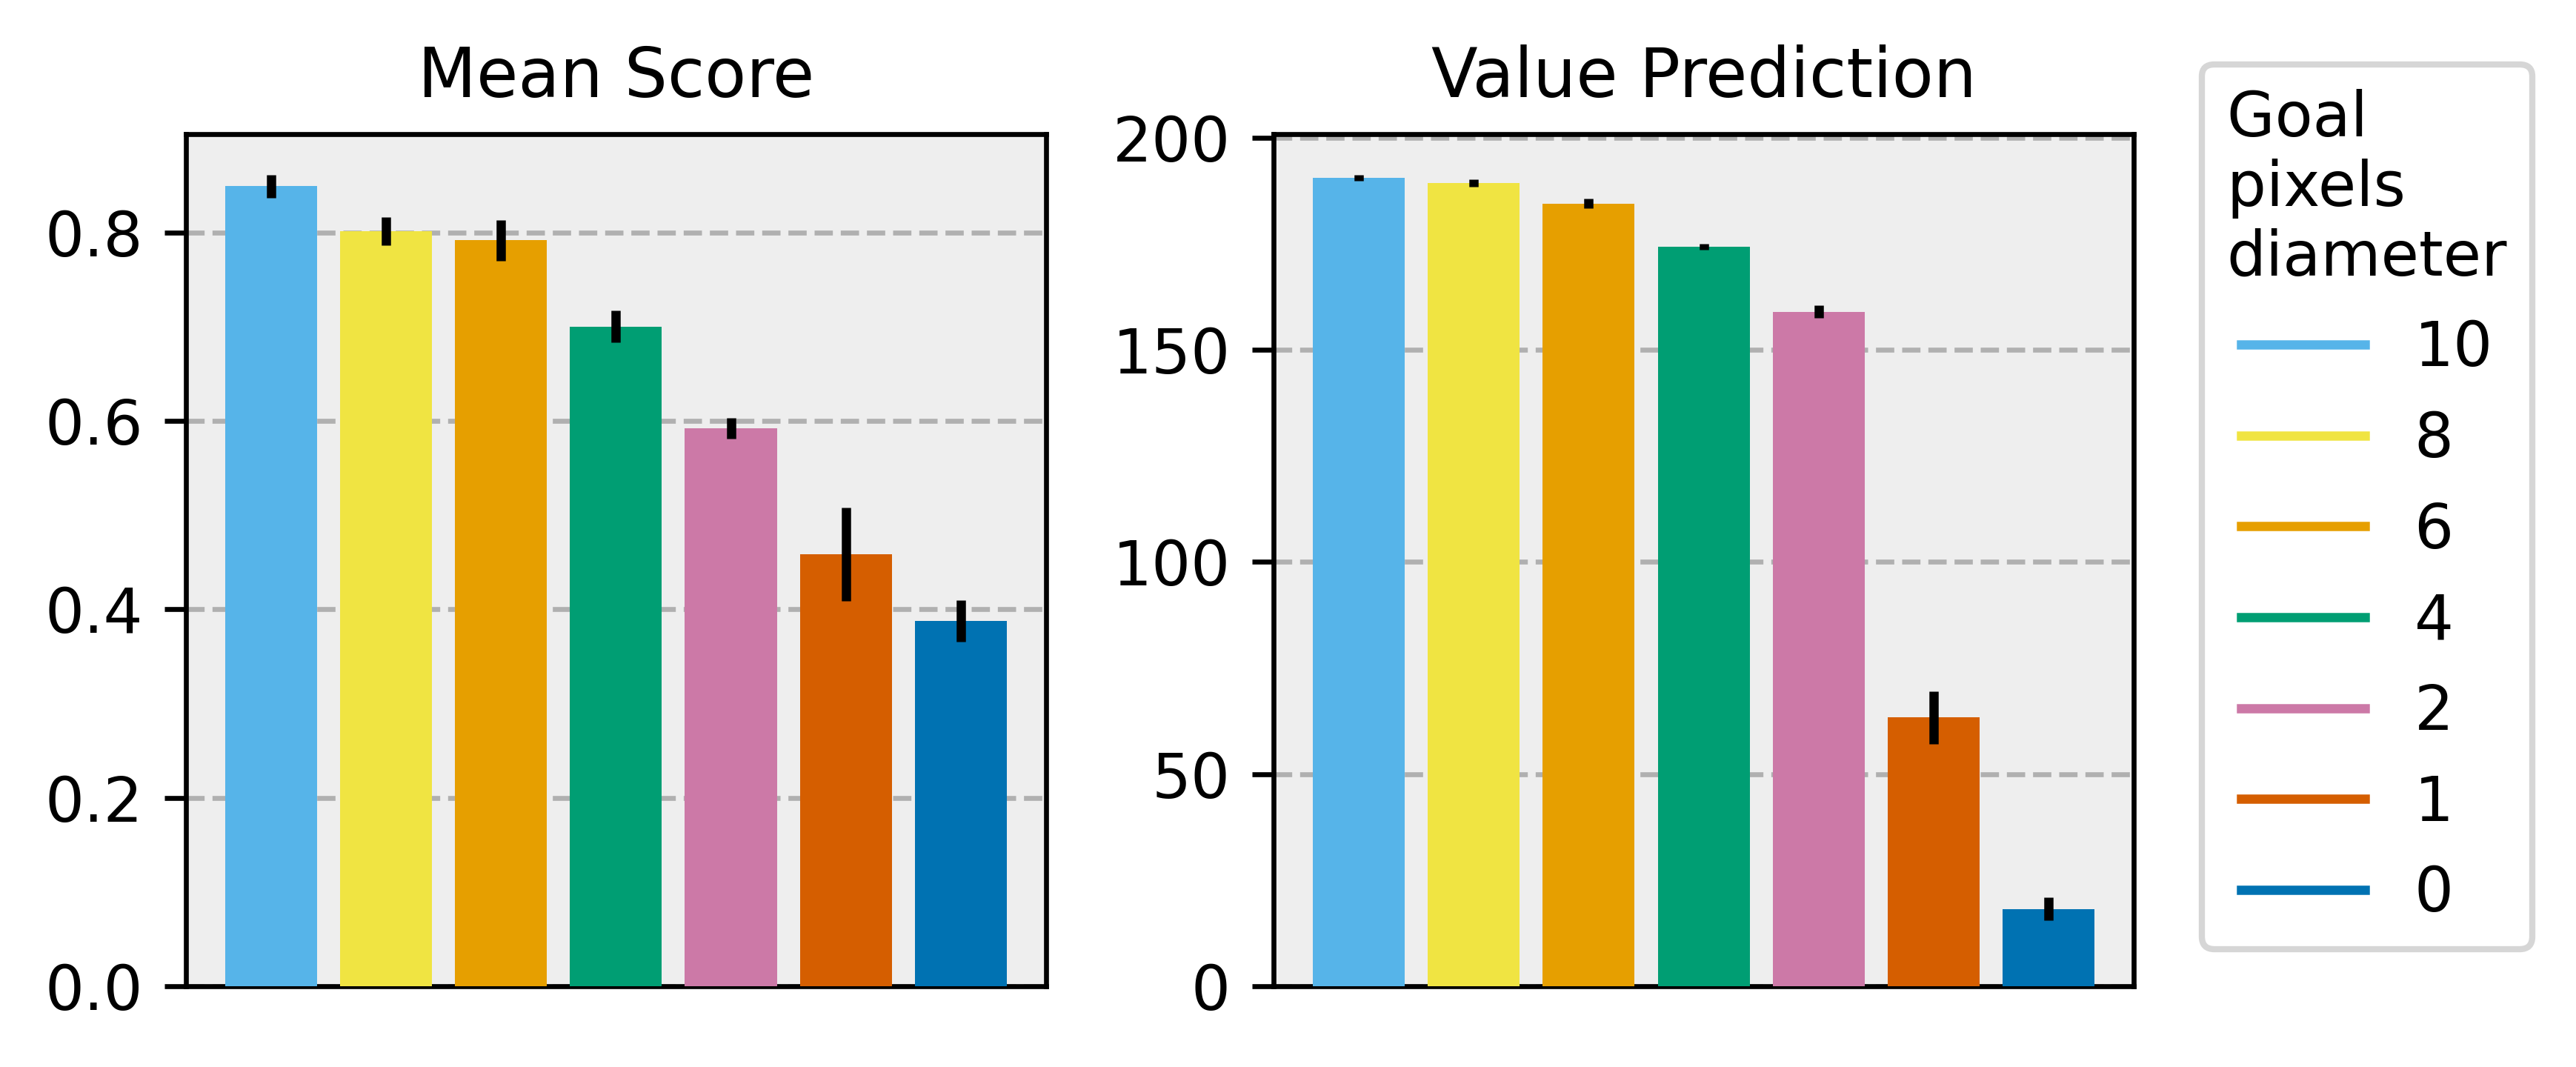

In [9]:
import itertools
from utils import colors
import collections

metrics_keys = ['train/move_to_target_mean', 'train/critic']
columns = metrics_keys
n_columns = len(columns)

if plotting:
    fig, rc_axes = plt.subplots(1, n_columns, figsize=(2.5 * n_columns,2.5))
    fig.set_facecolor('#ffffff')

max_handles, max_labels = [[],[]]
all_printing = {}

for i, param in enumerate(columns):
    if plotting:
        nl = '\n'
        rc_axes[i].set_title(f"{metrics_title[param]}", fontsize=11)
    if printing:
        print("Set", f"{columns[0]} - {columns[1]}")
    task_printing = {}
    
    # formatting of graph
    if plotting:
        ax = rc_axes[i]
        # if i == 0:
            # ax.set_ylabel(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=12)
        ax.set_facecolor('#eeeeee')
        ax.grid(visible=True, which='major', axis='y', linestyle='--',)
        # ax.set_xlim(0, 5e5)
        ax.set_xticks([])
        # ax.set_xticklabels(['0','20k', '50k', '100k'], fontsize=11)
    
    x = np.arange(len(plt_data))
    plt_data_sorted = collections.OrderedDict(sorted(plt_data.items())[::-1])
    
    for j, diam in enumerate(plt_data_sorted):
        print(diam)
        if plotting:
            y = plt_data[diam]
            # x = np.array([i for i in range(len(y))])

            kernel_size = 20
            kernel = np.ones(kernel_size) / kernel_size
            convolved_y = np.stack([np.convolve(z, kernel, mode='valid') for z in plt_data[diam][param]])
            Y_Final = convolved_y.mean(axis=0)
            Y_std = convolved_y.std(axis=0)
            
            # X_Final = np.array([i for i in range(len(Y_Final))]) * 3500
            y = Y_Final[-1]
            std = Y_std[-1]/np.sqrt(3)
            label = f"{diam}"
            # ax.plot(X_Final, Y_Final, label=label, color=diam2color[str(diam)])
            ax.bar(x[j], y, label=label, yerr=std, color=diam2color[str(diam)], zorder=3)
            handles, labels = ax.get_legend_handles_labels()
            if len(handles) > len(max_handles):
                max_handles, max_labels = ax.get_legend_handles_labels()
                                         
    
if plotting:
    legend_elements = [plt.Line2D([0], [0], color=diam2color[str(diam)], label=diam) for j, diam in enumerate(diam2color.keys())]
    fig.legend(handles=legend_elements, loc='upper center', ncol=1, bbox_to_anchor=(1.075,0.95), title="Goal \npixels \ndiameter")

    # by_label = dict(zip(max_labels, max_handles))
    # fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=len(by_label), bbox_to_anchor=(0.5,1.01))
    plt.tight_layout()

    fig.savefig(f'target_ablation_bar.png', facecolor=fig.get_facecolor(), bbox_inches='tight', format='png')

In [17]:
import collections
plt_data.keys()

collections.OrderedDict(sorted(plt_data.items())).keys()

odict_keys([0, 1, 2, 4, 6, 8, 10])

NameError: name 'ordered_tasks' is not defined

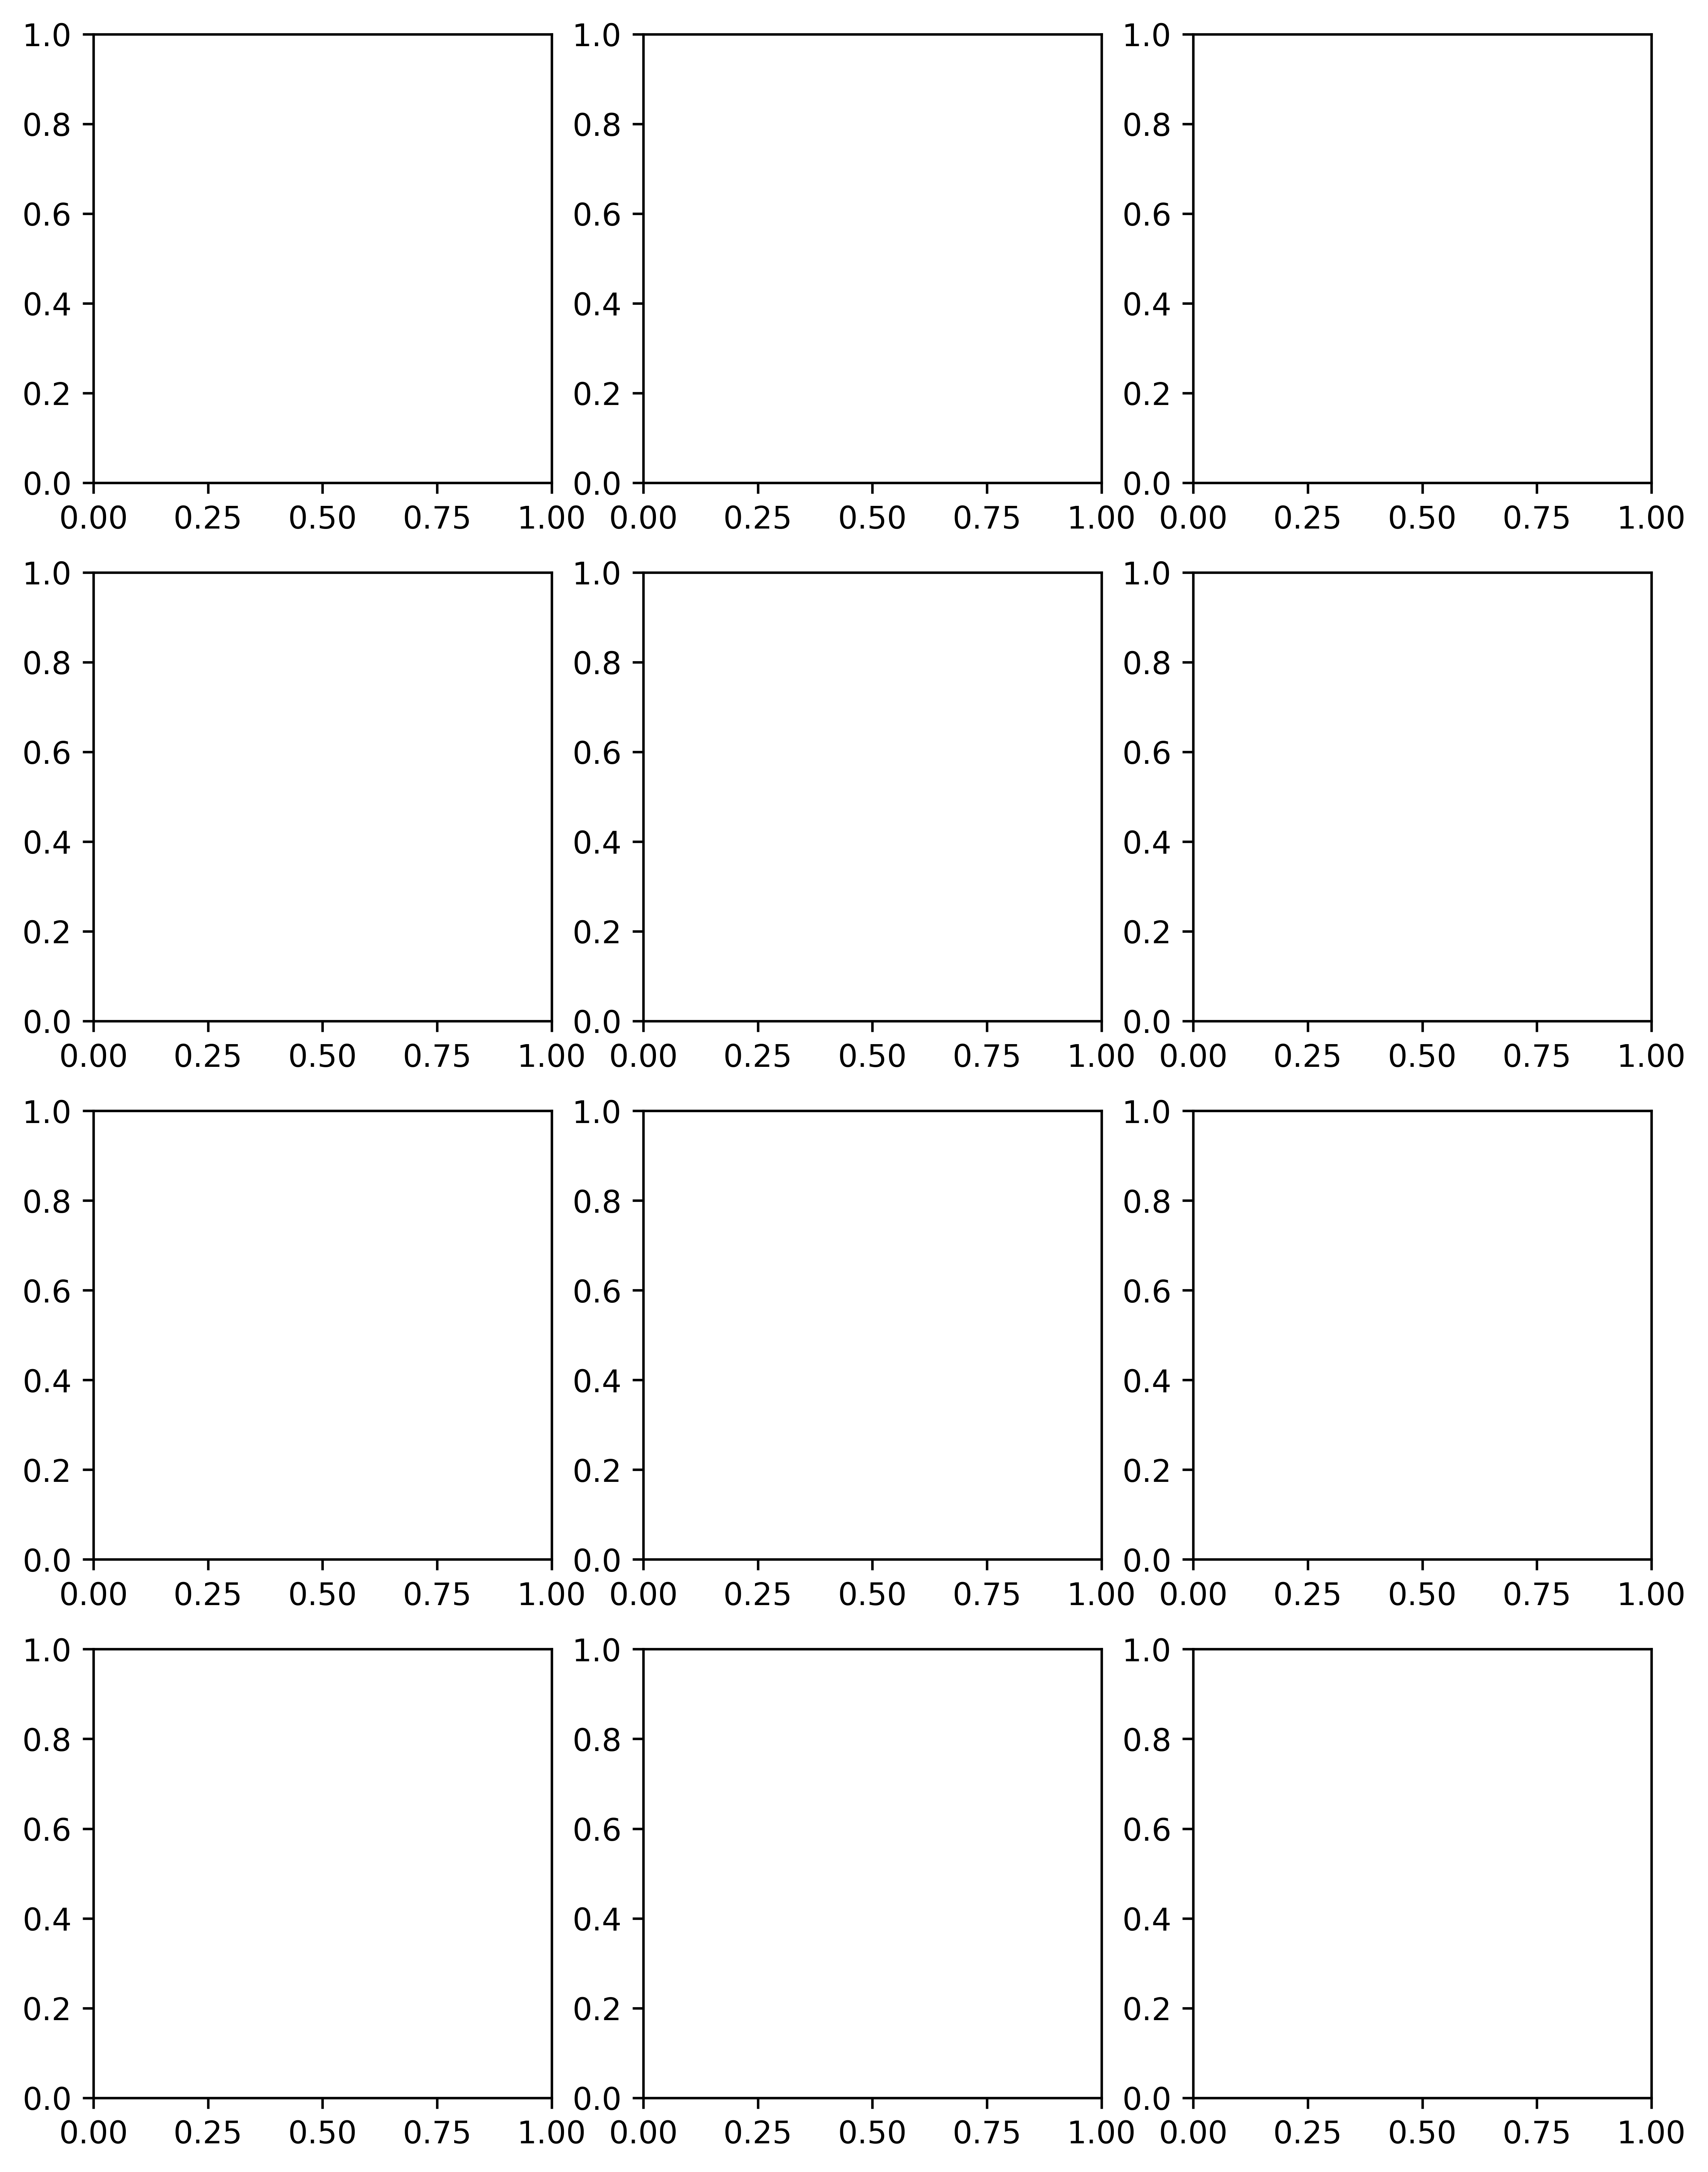

In [32]:
import itertools

expl_keys = ["dreamer", "p2e", "focus"]
vis_target_keys = [False]
columns = list(itertools.product(expl_keys, vis_target_keys))

n_columns = len(columns)
n_metrics = len(metrics_keys) 

if plotting:
    fig, rc_axes = plt.subplots(n_metrics, n_columns, figsize=(3 * n_columns,3 * n_metrics))
    fig.set_facecolor('#ffffff')
    fig.suptitle(ordered_tasks[task], x=0.1, y=1.01, fontsize=16, fontweight='bold')

max_handles, max_labels = [[],[]]
all_printing = {}

for i, param in enumerate(columns):
    if plotting:
        nl = '\n'
        rc_axes[0][i].set_title(f"expl. dataset: {param[0]} {nl} visual target: {param[1]}", fontsize=11)
    if printing:
        print("Set", f"{columns[0]} - {columns[1]}")
    task_printing = {}
    
    for j, metric in enumerate(metrics_keys):
        # formatting of graph
        if plotting:
            ax = rc_axes[j][i]
            if i == 0:
                ax.set_ylabel(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=12)
            ax.set_facecolor('#eeeeee')
            ax.grid(visible=True, which='major', axis='y', linestyle='--',)
            ax.set_xlim(0, 5e5)
            ax.set_xticks([0,100e3, 250e3, 500e3])
            ax.set_xticklabels(['0','100k', '250k', '500k'], fontsize=14)
        if printing:
            print("  ", "Metric", metric)
            metrics_printing = {}
        
        for agent in plt_data[task]:
            if plotting:
                y = plt_data[task][agent][metric]
                x = np.array([i for i in range(len(y))])

                kernel_size = 10
                kernel = np.ones(kernel_size) / kernel_size
                convolved_y = np.stack([np.convolve(z, kernel, mode='valid') for z in plt_data[task][agent][param[0]][param[1]][metric]])
                Y_Final = convolved_y.mean(axis=0)
                X_Final = np.array([i for i in range(len(Y_Final))]) * 2600

                ax.plot(X_Final, Y_Final, label=agent, color=agent2color[agent])

                handles, labels = ax.get_legend_handles_labels()
                if len(handles) > len(max_handles):
                    max_handles, max_labels = ax.get_legend_handles_labels()
            if printing:
                if metric in ['train/contact', 'train/pos_displacement', 'train/ang_displacement', 'train/vertical_displacement']:
                    summary_data = plt_data[task][agent][param[0]][param[1]][metric].mean(axis=1)
                else:
                    summary_data = plt_data[task][agent][param[0]][param[1]][metric].sum(axis=1)
                metrics_printing[agent] = [summary_data.mean(axis=0), summary_data.std(axis=0) / np.sqrt(len(summary_data)) ]
        task_printing[metric] = deepcopy(metrics_printing)
        if printing:
            for agent in agent2label:
                if agent in metrics_printing:
                    print("    ", agent2label[agent], np.round(metrics_printing[agent][0], 2), '±', np.round(metrics_printing[agent][1], 2))                             
    all_printing[task] = deepcopy(task_printing)
    
if plotting:
    legend_elements = [plt.Line2D([0], [0], color=agent2color[agent], label=agent2label[agent]) for agent in agent2color]
    fig.legend(handles=legend_elements, loc='upper center', ncol=len(legend_elements), bbox_to_anchor=(0.5,0.99))

    # by_label = dict(zip(max_labels, max_handles))
    # fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=len(by_label), bbox_to_anchor=(0.5,1.01))
    plt.tight_layout()

    fig.savefig(f'{task}.png', facecolor=fig.get_facecolor(), bbox_inches='tight', format='png')

In [84]:
table = []
# table.append([task for task in all_printing])
# domains = set([task.replace('_push', '').replace('-push', '').replace('-lift', '').replace('-turn', '') for task in all_printing]) 
for domain in ordered_domains:
#     print(domain)
    domain_rows = []
    for task in all_printing:
        if domain not in task:
            continue
        for agent in agent2label:
            row = ["",]
    #         row.append(agent2label[agent])
            for metric in all_printing[task]:
                if metric in ['train/vertical_displacement',]:
                    continue
                if agent in all_printing[task][metric]:
                    value = str(np.round(all_printing[task][metric][agent][0], 2))
                else:
                    value = str(0.0)
                if metric == 'train/episode_reward':
                    if 'push' in task:
                        row = row + [value ,'-', '-']
                    if 'lift' in task:
                        row = row + ['-', value ,'-']
                    if 'turn' in task:
                        row = row + ['-', '-', value]
                else:    
                    row.append(value)
            row.append("")
            domain_rows.append(row)
    if len(domain_rows) > 4:
#         print(len(domain_rows))
        def fake_sum(a, b):
#             print(a, b)
            if a == '-':
                if b =='-':
                    return '-'
                else:
                    return b
            if b == '-':
                return a
            return str( np.round((float(a)+float(b))/2, 2) )
        t1 = deepcopy(domain_rows[:4])
        t2 = deepcopy(domain_rows[4:])
        domain_rows = [['',] + [ fake_sum(t1[i][j], t2[i][j]) for j in range(1, len(t1[i])-1)] + ['',] for i in range(len(t1))]
    table += domain_rows
for row in table:
#     pass
    print(" | ".join(row))

 | 0.04 | 0.15 | 1.86 | 3.5 | 37.45 | 0.06 | 0.15 | 0.01 | 0.67 | - | - | 
 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 
 | 0.0 | 0.0 | 0.01 | 0.0 | 0.15 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 
 | 0.0 | 0.01 | 0.15 | 0.01 | 0.11 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 
 | 0.1 | 0.4 | 4.46 | 0.0 | 0.0 | 0.53 | 0.0 | 0.0 | - | 0.0 | - | 
 | 0.0 | 0.01 | 0.01 | 0.0 | 0.0 | 0.16 | 0.0 | 0.0 | - | 0.0 | - | 
 | 0.0 | 0.01 | 0.01 | 0.0 | 0.0 | 0.3 | 0.0 | 0.0 | - | 0.0 | - | 
 | 0.01 | 0.03 | 0.25 | 0.06 | 0.0 | 5.05 | 0.0 | 0.03 | - | 2.0 | - | 
 | 0.12 | 0.0 | 1.22 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 101.67 | 
 | 0.0 | 0.0 | 0.01 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 0.0 | 
 | 0.1 | 0.0 | 1.23 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 35.33 | 
 | 0.08 | 0.0 | 0.98 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 34.33 | 
 | 0.08 | 0.38 | 3.5 | 1.31 | 25.28 | 0.72 | 6.08 | 7.12 | 38.67 | 27.0 | - | 
 | 0.0 | 0.0 | 0.06 | 0.04 | 0.22 | 0.02 | 0.16 | 0.29 | 2.67 | 0.67 | - | 
 | 0.02 | 0.

|  Contact | Pos Disp | Ang Disp | Reward |       |       |       |       | Placement |   |   |
|:-------:|:--------:|:--------:|:------:|:-----:|:-----:|:-----:|:-----:|:---------:|:-:|:-:|
|                 |       |         |         |          |          |    P   |   L   |   T   | Up    | ↑     | ↓         | ← | → |
 | 0.04 | 1.86 | 0.15 | 3.5 | 37.45 | 0.06 | 0.15 | 0.01 | 0.67 | - | - | 
 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 
 | 0.0 | 0.01 | 0.0 | 0.0 | 0.15 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 
 | 0.0 | 0.15 | 0.01 | 0.01 | 0.11 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 
 | 0.1 | 4.46 | 0.4 | 0.0 | 0.0 | 0.53 | 0.0 | 0.0 | - | 0.0 | - | 
 | 0.0 | 0.01 | 0.01 | 0.0 | 0.0 | 0.16 | 0.0 | 0.0 | - | 0.0 | - | 
 | 0.0 | 0.01 | 0.01 | 0.0 | 0.0 | 0.3 | 0.0 | 0.0 | - | 0.0 | - | 
 | 0.01 | 0.25 | 0.03 | 0.06 | 0.0 | 5.05 | 0.0 | 0.03 | - | 2.0 | - | 
 | 0.12 | 1.22 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 101.67 | 
 | 0.0 | 0.01 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 0.0 | 
 | 0.1 | 1.23 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 35.33 | 
 | 0.08 | 0.98 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | 0.0 | - | - | 34.33 | 
 | 0.08 | 3.5 | 0.38 | 1.31 | 25.28 | 0.72 | 6.08 | 7.12 | 38.67 | 27.0 | - | 
 | 0.0 | 0.06 | 0.0 | 0.04 | 0.22 | 0.02 | 0.16 | 0.29 | 2.67 | 0.67 | - | 
 | 0.02 | 0.97 | 0.11 | 0.64 | 8.48 | 0.22 | 4.78 | 4.14 | 19.67 | 14.67 | - | 
 | 0.01 | 0.4 | 0.04 | 0.24 | 2.0 | 0.98 | 1.3 | 2.1 | 6.67 | 5.33 | - | 
 | 0.05 | 5.78 | 0.49 | 0.17 | 145.66 | 28.57 | 61.51 | 62.8 | 507.67 | 2.67 | - | 
 | 0.02 | 3.04 | 0.26 | 0.08 | 85.68 | 24.02 | 24.34 | 46.35 | 628.67 | 0.33 | - | 
 | 0.03 | 3.26 | 0.29 | 0.12 | 69.95 | 30.63 | 29.72 | 36.0 | 207.67 | 2.33 | - | 
 | 0.01 | 1.56 | 0.14 | 0.06 | 23.64 | 23.74 | 15.88 | 13.52 | 68.33 | 1.67 | - | 

7984
7984
7984
7984
829
7984
7984
12406
11984
11984
11984
11984
11984
7984
7932
7816
7984
7820
7984
rsPanda_CustomLift
(3, 7984)
(3, 7984)
rsPanda_CustomStack
(3, 11984)
(3, 11984)
msPanda_TurnFaucet_
(3, 7800)
(3, 7800)


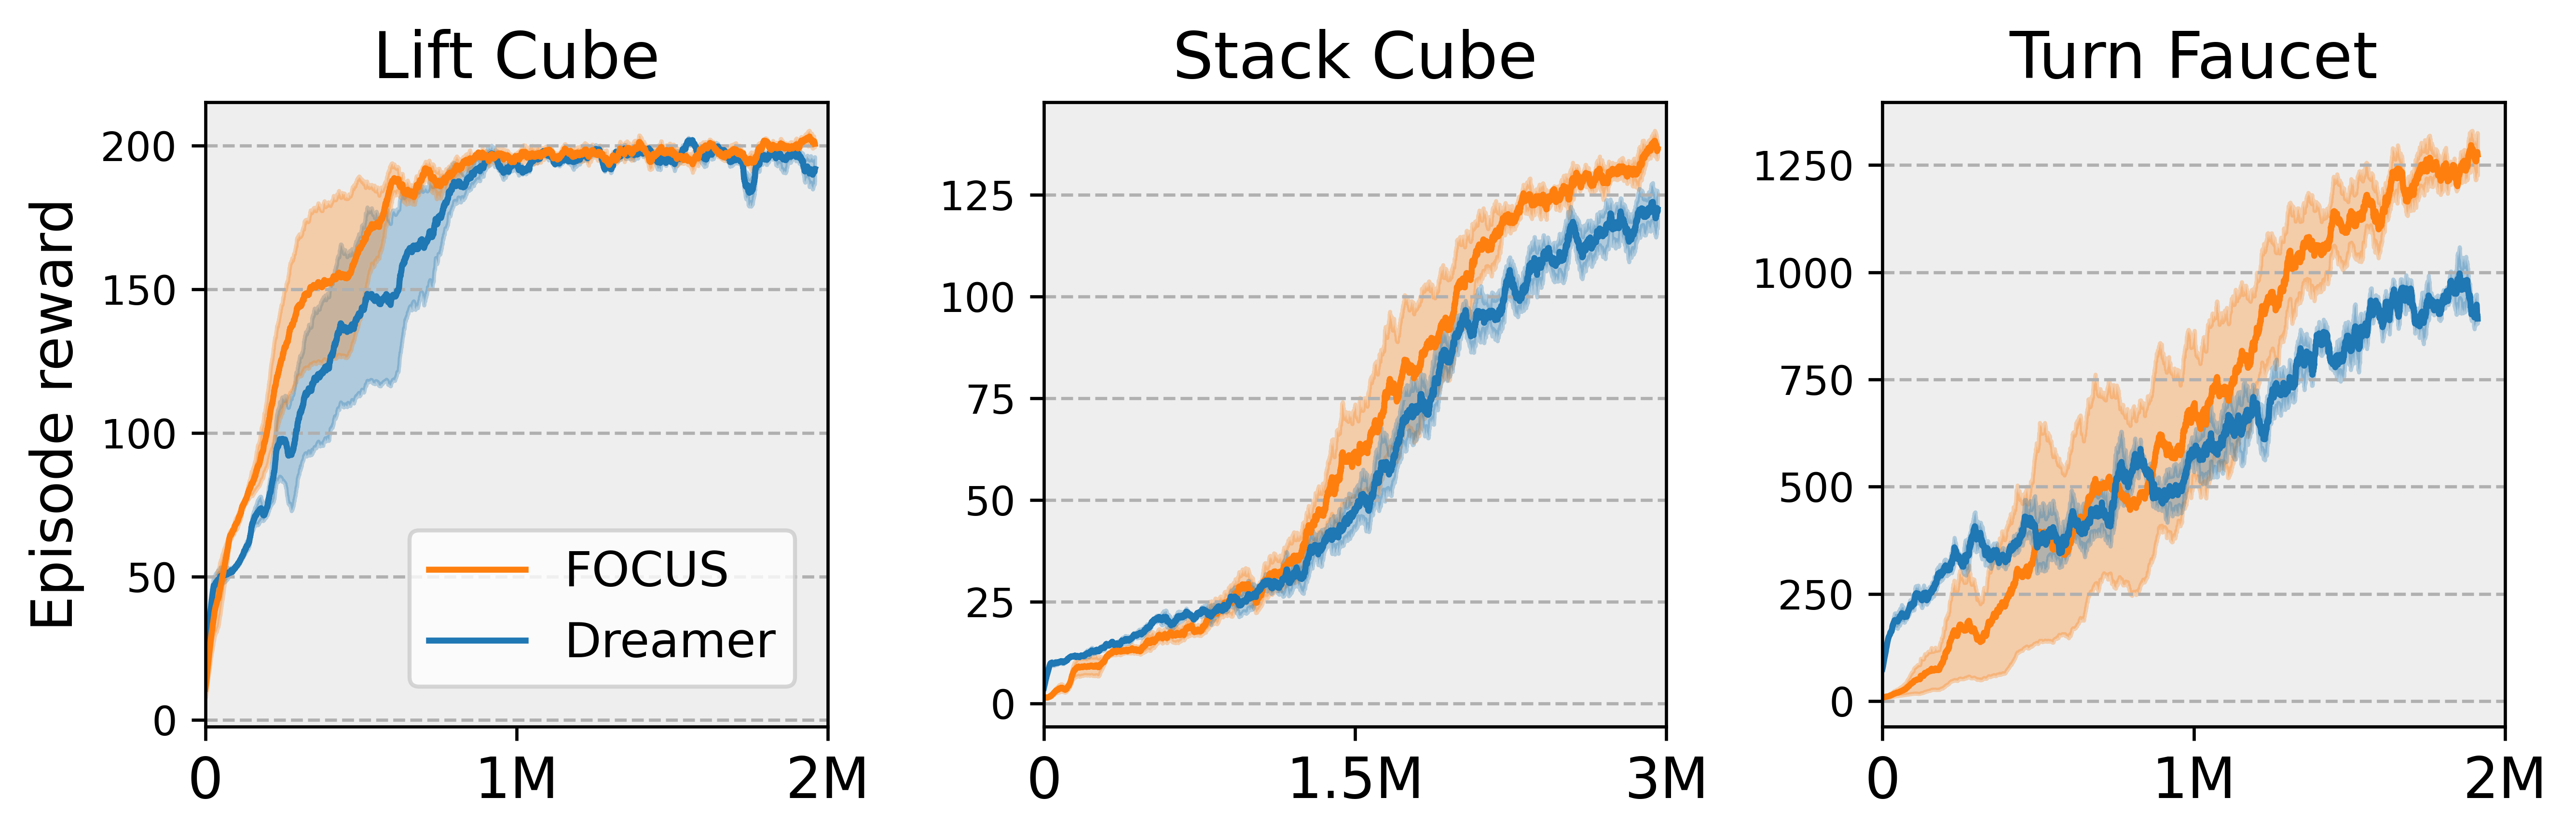

In [63]:
assert project_key == 'RSS_task'

ordered_domains = OrderedDict({
    'rsPanda_CustomLift' : 'Lift Cube',
    'rsPanda_CustomStack' : 'Stack Cube',
    'msPanda_TurnFaucet_' : "Turn Faucet",
#     'msPanda_PickSingleYCB_011_banana' : "Banana",
#     'msPanda_PickSingleYCB_002_master_chef_can' : "Master Chef Can",
})

ordered_limits = OrderedDict({
    'rsPanda_CustomLift' : 7984,
    'rsPanda_CustomStack' : 11984,
    'msPanda_TurnFaucet_' : 7800,
#     'msPanda_PickSingleYCB_011_banana' : "Banana",
#     'msPanda_PickSingleYCB_002_master_chef_can' : "Master Chef Can",
})


plt_data = defaultdict(lambda: defaultdict(lambda : defaultdict(list)))
"""
Notes:
- train/episode_reward only > 0
- summing values over episode apart from some metrics 'train/contact', 'train/pos_displacement', 'train/ang_displacement', 'train/vertical_displacement'
"""

metrics_keys = deepcopy(expl_metrics_keys)

all_tasks = set([data_dict.item()['task'] for data_dict in all_data])

agent2label = OrderedDict({
    'dreamer_obj'  : 'FOCUS',
    'dreamer'      : 'Dreamer',
})

agent2color = OrderedDict({
    'dreamer_obj'  : 'C1',
    'dreamer'      : 'C0',
})

task_metrics_keys = ['train/episode_reward',]

limit = 7984 if project_key == 'RSS_explore' else 7984 // 2

plotting = True
printing = False

# Organize data
for domain in ordered_domains:
    for data_dict in all_data:
        if domain in data_dict.item()['task']:
            agent = data_dict.item()['agent']
            for k in task_metrics_keys:
#                 if 'Lift' in domain and agent == 'dreamer_obj':
                    # TO fix bug with wandb (it looks like it's rescaling by 4/3)
#                     plt_data[domain][agent][k].append(data_dict.item()[k][:3980]*1.3)
#                 if len(data_dict.item()[k]) > 3980:
                print(len(data_dict.item()[k]))
                if len(data_dict.item()[k]) < 1000:
                    continue
                plt_data[domain][agent][k].append(data_dict.item()[k][:ordered_limits[domain]])
#                 else:
#                 plt_data[domain][agent][k].append(data_dict.item()[k][:3830])

                    # Aggregate data
for task in plt_data:
    for agent in plt_data[task]:
        for k in plt_data[task][agent]:
#             [print(a.shape) for a in plt_data[task][agent][k]]
            plt_data[task][agent][k] = np.stack(plt_data[task][agent][k], axis=0)

all_tasks = list(plt_data.keys())
n_tasks = len(plt_data)
n_metrics = len(task_metrics_keys) 
if plotting:
    fig, rc_axes = plt.subplots(n_metrics, n_tasks, figsize=(3 * n_tasks, 3))
    fig.set_facecolor('#ffffff')
    
    if len(task_metrics_keys) == 1:
        rc_axes = [rc_axes]
    

max_handles, max_labels = [[],[]]
all_printing = {}
for i, task in enumerate(all_tasks):
    if plotting:
        rc_axes[0][i].set_title(ordered_domains[task], fontsize=16)
    if printing:
        print("Task", task)
    task_printing = {}
    for j, metric in enumerate(task_metrics_keys):
        if plotting:
            ax = rc_axes[j][i]
            ax.set_facecolor('#eeeeee')
            ax.grid(visible=True, which='major', axis='y', linestyle='--',)
            print(task)
            if task == 'rsPanda_CustomLift': ax.set_ylabel(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=14)
            if task == 'rsPanda_CustomStack':
                ax.set_xlim(0, 3e6)
                ax.set_xticks([0, 1.5e6, 3e6])
                ax.set_xticklabels(['0', '1.5M', '3M'], fontsize=14)
            else:
                ax.set_xlim(0, 2e6)
                ax.set_xticks([0, 1e6, 2e6])
                ax.set_xticklabels(['0', '1M', '2M'], fontsize=14)
        if printing:
            print("  ", "Metric", metric)
            metrics_printing = {}
        for agent in plt_data[task]:
            if plotting:
                print(plt_data[task][agent][metric].shape)
                y = Y_Final = plt_data[task][agent][metric].mean(axis=0)                
                x = X_Final = np.array([i for i in range(len(y))]) * 250
                
                
                kernel_size = 150
                kernel = np.ones(kernel_size) / kernel_size
                convolved_y = np.stack([np.convolve(z, kernel, mode='valid') for z in plt_data[task][agent][metric]])
                Y_Final = convolved_y.mean(axis=0)
                X_Final = np.array([i for i in range(len(Y_Final))]) * 250
                ax.plot(X_Final, Y_Final, label=agent2label[agent], color=agent2color[agent])
                ax.fill_between(X_Final, Y_Final - convolved_y.std(axis=0) / np.sqrt(convolved_y.shape[0]), Y_Final + convolved_y.std(axis=0) / np.sqrt(convolved_y.shape[0]), alpha=0.3, label=agent2label[agent], color=agent2color[agent])
                
#                 X_Final = x[:]
                
#                 B_spline_coeff = make_interp_spline(x, y,)
#                 X_Final = np.linspace(x.min(), x.max(), int(500) )
#                 Y_Final = np.clip(B_spline_coeff(X_Final), 0, np.inf)
                

                handles, labels = ax.get_legend_handles_labels()
                if len(handles) > len(max_handles):
                    max_handles, max_labels = ax.get_legend_handles_labels()
            if printing:
                if metric in ['train/contact', 'train/pos_displacement', 'train/ang_displacement', 'train/vertical_displacement']:
                    summary_data = plt_data[task][agent][metric].mean(axis=1)
                else:
                    summary_data = plt_data[task][agent][metric].sum(axis=1)
                metrics_printing[agent] = [summary_data.mean(axis=0), summary_data.std(axis=0) / np.sqrt(len(summary_data)) ]
        if printing:
            task_printing[metric] = deepcopy(metrics_printing)
            for agent in agent2label:
                if agent in metrics_printing:
                    print("    ", agent2label[agent], np.round(metrics_printing[agent][0], 2), '±', np.round(metrics_printing[agent][1], 2))                             
    all_printing[task] = deepcopy(task_printing)
    
if plotting:
    legend_elements = [plt.Line2D([0], [0], color=agent2color[agent], label=agent2label[agent]) for agent in agent2color]
    fig.legend(handles=legend_elements, ncol=1, bbox_to_anchor=(0.32,0.4), fontsize=12)

    # by_label = dict(zip(max_labels, max_handles))
    # fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=len(by_label), bbox_to_anchor=(0.5,1.01))
    plt.tight_layout()

    fig.savefig(f'{project_key}_task.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')

1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
1984
784
784
784
784
784
784
784
784
784
1984
1984
1984
1984
1984
1984
1984
1984
1984
msPanda_PickSingleYCB_011_banana
(6, 1980)
(6, 1980)
(6, 1980)
msPanda_TurnFaucet_-turn
(3, 780)
(3, 780)
(3, 780)
msPanda_PickSingleYCB_002_master_chef_can
(3, 1980)
(3, 1980)
(3, 1980)


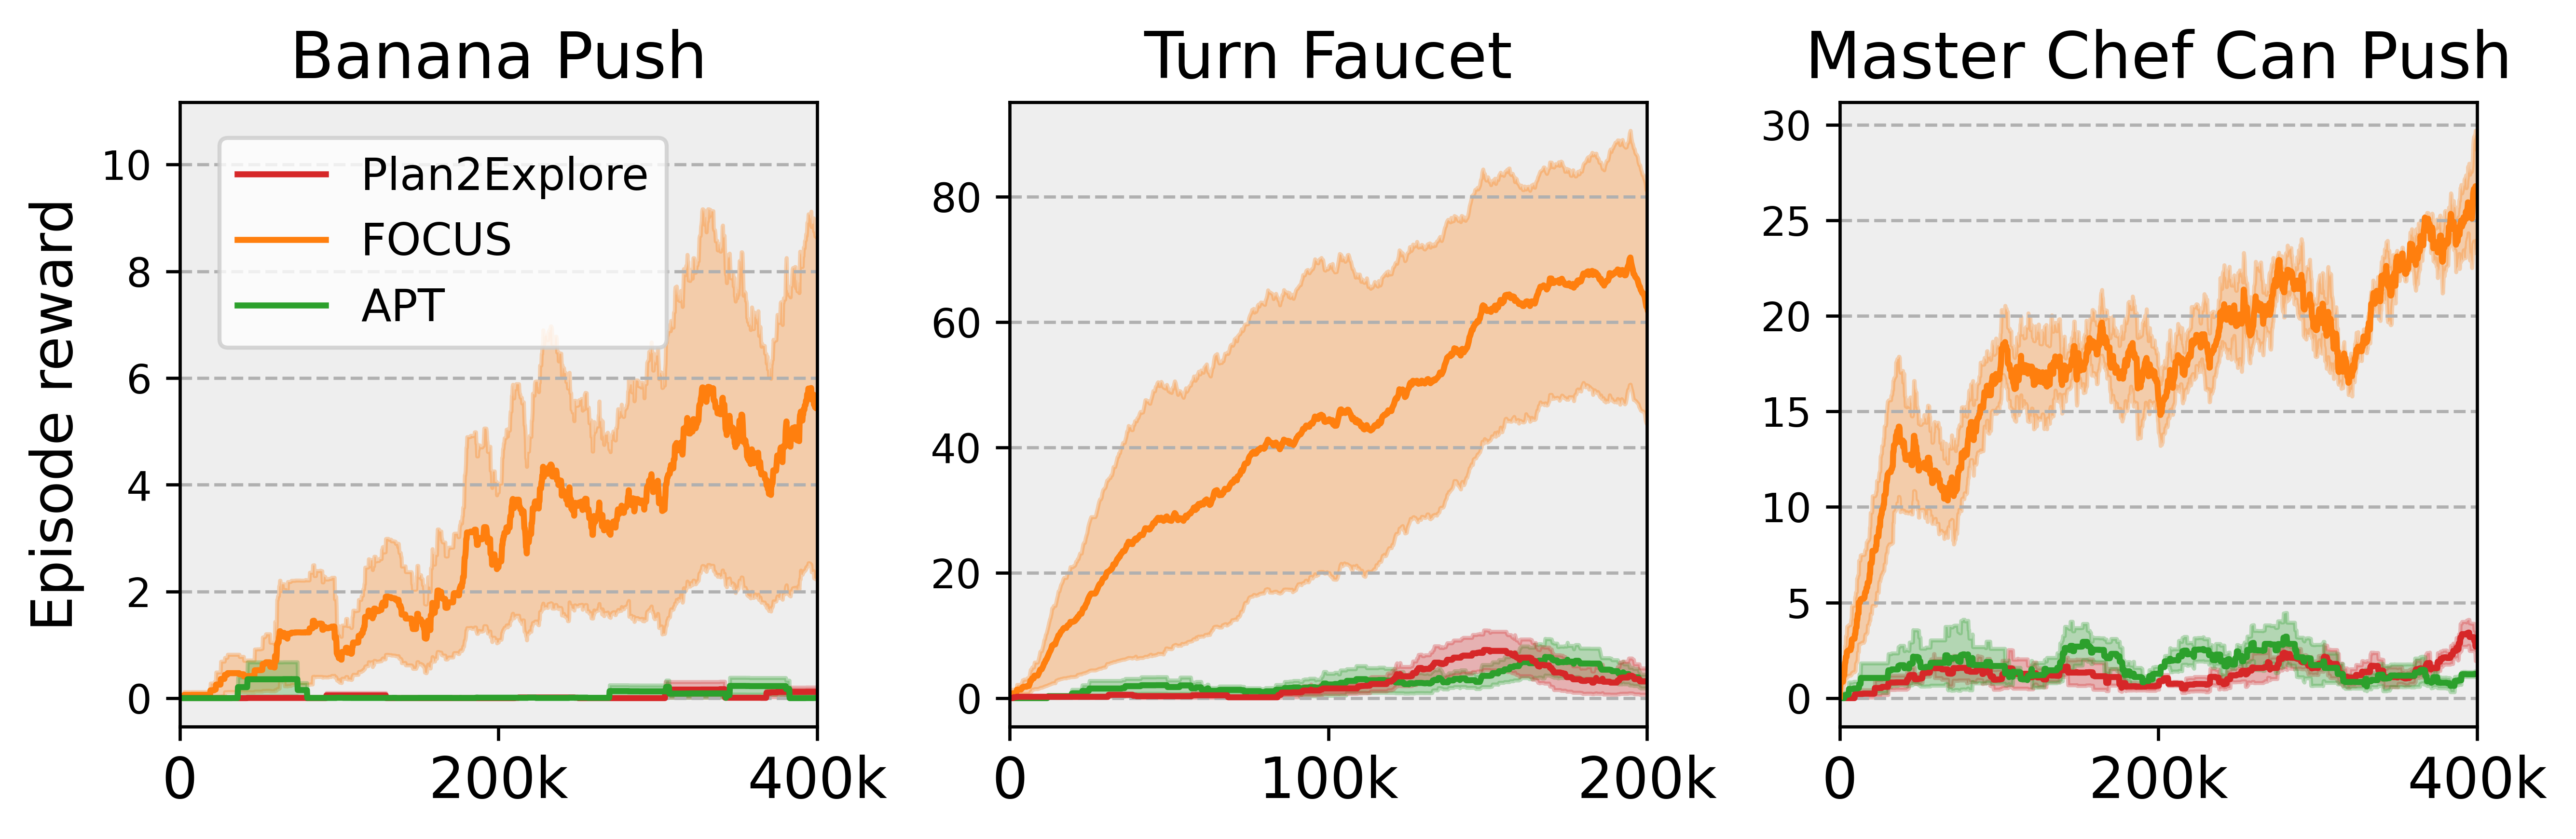

In [69]:
assert project_key == 'RSS_finetune'


ordered_domains = OrderedDict({
#     'rsPanda_CustomLift' : 'Lift Cube',
#     'rsPanda_CustomStack' : 'Stack Cube',
    'msPanda_PickSingleYCB_011_banana' : "Banana Push",
    'msPanda_TurnFaucet_-turn' : "Turn Faucet",
    'msPanda_PickSingleYCB_002_master_chef_can' : "Master Chef Can Push",
})

ordered_limits = OrderedDict({
#     'rsPanda_CustomLift' : 7984,
#     'rsPanda_CustomStack' : 11984,
    'msPanda_PickSingleYCB_011_banana' : 1980,
    'msPanda_TurnFaucet_-turn' : 780,
    'msPanda_PickSingleYCB_002_master_chef_can' : 1980,
})


plt_data = defaultdict(lambda: defaultdict(lambda : defaultdict(list)))
"""
Notes:
- train/episode_reward only > 0
- summing values over episode apart from some metrics 'train/contact', 'train/pos_displacement', 'train/ang_displacement', 'train/vertical_displacement'
"""

metrics_keys = deepcopy(expl_metrics_keys)

all_tasks = set([data_dict.item()['task'] for data_dict in all_data])

agent2label = OrderedDict({
    'plan2explore'  : 'Plan2Explore',
    'dreamer_obj'  : 'FOCUS',
    'apt_dreamer'  : 'APT',
})

agent2color = OrderedDict({
    'plan2explore'      : 'C3',
    'dreamer_obj'  : 'C1',
    'apt_dreamer'      : 'C2',
})

task_metrics_keys = ['train/episode_reward',]

limit = 7984 if project_key == 'RSS_explore' else 7984 // 2

plotting = True
printing = False

# Organize data
for domain in ordered_domains:
    for data_dict in all_data:
        if domain in data_dict.item()['task']:
            agent = data_dict.item()['agent']
            for k in task_metrics_keys:
#                 if 'Lift' in domain and agent == 'dreamer_obj':
                    # TO fix bug with wandb (it looks like it's rescaling by 4/3)
#                     plt_data[domain][agent][k].append(data_dict.item()[k][:3980]*1.3)
#                 if len(data_dict.item()[k]) > 3980:
                print(len(data_dict.item()[k]))
                if len(data_dict.item()[k]) < 500:
                    continue
                plt_data[domain][agent][k].append(data_dict.item()[k][:ordered_limits[domain]])
#                 else:
#                 plt_data[domain][agent][k].append(data_dict.item()[k][:3830])

                    # Aggregate data
for task in plt_data:
    for agent in plt_data[task]:
        for k in plt_data[task][agent]:
#             [print(a.shape) for a in plt_data[task][agent][k]]
            plt_data[task][agent][k] = np.stack(plt_data[task][agent][k], axis=0)

all_tasks = list(plt_data.keys())
n_tasks = len(plt_data)
n_metrics = len(task_metrics_keys) 
if plotting:
    fig, rc_axes = plt.subplots(n_metrics, n_tasks, figsize=(3 * n_tasks, 3))
    fig.set_facecolor('#ffffff')
    
    if len(task_metrics_keys) == 1:
        rc_axes = [rc_axes]
    

max_handles, max_labels = [[],[]]
all_printing = {}
for i, task in enumerate(all_tasks):
    if plotting:
        rc_axes[0][i].set_title(ordered_domains[task], fontsize=16)
    if printing:
        print("Task", task)
    task_printing = {}
    for j, metric in enumerate(task_metrics_keys):
        if plotting:
            ax = rc_axes[j][i]
            ax.set_facecolor('#eeeeee')
            ax.grid(visible=True, which='major', axis='y', linestyle='--',)
            print(task)            
            ax = rc_axes[j][i]
            
            if task == 'msPanda_PickSingleYCB_011_banana':
                ax.set_ylabel(metric.replace('train/','').replace('_',' ').capitalize(), fontsize=14)
                
            if task == 'msPanda_TurnFaucet_-turn':
                ax.set_xlim(0, 200e3)
                ax.set_xticks([0, 100e3, 200e3])
                ax.set_xticklabels(['0','100k', '200k'], fontsize=14)
            else:
                ax.set_xlim(0, 400e3)
                ax.set_xticks([0,200e3, 400e3]) #, 1e6, 1.5e6, 2e6])
                ax.set_xticklabels(['0','200k', '400k'], fontsize=14) #, '1M', '1.5M', '2M'], fontsize=14)
        if printing:
            print("  ", "Metric", metric)
            metrics_printing = {}
        for agent in plt_data[task]:
            if plotting:
                print(plt_data[task][agent][metric].shape)
                y = Y_Final = plt_data[task][agent][metric].mean(axis=0)                
                x = X_Final = np.array([i for i in range(len(y))]) * 250
                
                
                kernel_size = 150
                kernel = np.ones(kernel_size) / kernel_size
                convolved_y = np.stack([np.convolve(z, kernel, mode='full') for z in plt_data[task][agent][metric]])
                Y_Final = convolved_y.mean(axis=0)
                X_Final = np.array([i for i in range(len(Y_Final))]) * 250
                ax.plot(X_Final, Y_Final, label=agent2label[agent], color=agent2color[agent])
                ax.fill_between(X_Final, Y_Final - convolved_y.std(axis=0) / np.sqrt(convolved_y.shape[0]), Y_Final + convolved_y.std(axis=0) / np.sqrt(convolved_y.shape[0]), alpha=0.3, label=agent2label[agent], color=agent2color[agent])
                
#                 X_Final = x[:]
                
#                 B_spline_coeff = make_interp_spline(x, y,)
#                 X_Final = np.linspace(x.min(), x.max(), int(500) )
#                 Y_Final = np.clip(B_spline_coeff(X_Final), 0, np.inf)
                

                handles, labels = ax.get_legend_handles_labels()
                if len(handles) > len(max_handles):
                    max_handles, max_labels = ax.get_legend_handles_labels()
            if printing:
                if metric in ['train/contact', 'train/pos_displacement', 'train/ang_displacement', 'train/vertical_displacement']:
                    summary_data = plt_data[task][agent][metric].mean(axis=1)
                else:
                    summary_data = plt_data[task][agent][metric].sum(axis=1)
                metrics_printing[agent] = [summary_data.mean(axis=0), summary_data.std(axis=0) / np.sqrt(len(summary_data)) ]
        if printing:
            task_printing[metric] = deepcopy(metrics_printing)
            for agent in agent2label:
                if agent in metrics_printing:
                    print("    ", agent2label[agent], np.round(metrics_printing[agent][0], 2), '±', np.round(metrics_printing[agent][1], 2))                             
    all_printing[task] = deepcopy(task_printing)
    
if plotting:
    legend_elements = [plt.Line2D([0], [0], color=agent2color[agent], label=agent2label[agent]) for agent in agent2color]
    fig.legend(handles=legend_elements, ncol=1, bbox_to_anchor=(0.27,0.85), fontsize=11)

    # by_label = dict(zip(max_labels, max_handles))
    # fig.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=len(by_label), bbox_to_anchor=(0.5,1.01))
    plt.tight_layout()

    fig.savefig(f'{project_key}_finetune.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')

In [ ]:
all_data[0].item()

In [51]:
all_data

[array({'agent': 'apt_dreamer', 'task': 'msPanda_PickSingleYCB_011_banana-lift', 'comment': '011_banana-lift', 'seed': '1', 'train/contact': array([0.092, 0.064, 0.032, ..., 0.052, 0.052, 0.036]), 'train/pos_displacement': array([0.3979703 , 0.0970469 , 0.46282242, ..., 0.2750262 , 0.13319202,
        0.09349164]), 'train/ang_displacement': array([5.33396988, 0.31955003, 6.64506309, ..., 3.96084316, 0.61190953,
        0.03100335]), 'train/vertical_displacement': array([1.21084066e-01, 3.34234536e-03, 1.02385441e-01, ...,
        1.13858255e-01, 6.62183389e-03, 7.82310963e-08]), 'train/up_placement': array([0., 0., 0., ..., 0., 0., 0.]), 'train/far_placement': array([0., 0., 0., ..., 0., 0., 0.]), 'train/close_placement': array([0., 0., 0., ..., 0., 0., 0.]), 'train/left_placement': array([0., 0., 0., ..., 0., 0., 0.]), 'train/right_placement': array([0., 0., 0., ..., 0., 0., 0.]), 'train/episode_reward': array([0., 0., 0., ..., 0., 0., 0.]), 'train/success': array([0, 0, 0, ..., 0, 0,

# Below this point it's my old plotting stuff, keeping only for reference

In [ ]:
plt_data['dreamer']['train/contact'].shape

In [ ]:
agent

In [ ]:
data_dict

In [ ]:
# frame.where( (frame['init_reward']==True) & (frame['domain'] == 'jaco') ).dropna()

In [ ]:
np.unique(frame.where( ( frame['domain']=='jaco') & (frame['init_reward']==False) ).dropna()['agent'])

In [ ]:
# frame.where(frame['agent'].str.contains('diayn')).dropna()

In [ ]:
urlb_frame = pd.read_csv(f'urlb_pixels_all.csv', index_col=0, header=0)

In [ ]:
# Dreamer reference
# for t in reference:
#     cur = frame.where(frame['snapshot_ts'] == 2000000) \
#         .where(frame['agent'] == 'dreamer') \
#         .where(frame['task'] == t) \
#         .dropna()
#     print(t, len(cur), cur['eval_ret'].mean(), cur['eval_ret'].std()  )

In [ ]:
def create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, 
                exp="", top_space=0.95, bottom_space=0.05, legend_kwargs={}, legend_ncol=1,
               init_critic_opt=[False], init_reward_opt=[False], init_policy_opt=[True],
                print_info=False, overall=False, hide_legend=False, label_above=False, custom_figsize=False):
    matplotlib.rc('xtick', labelsize=14) 
    matplotlib.rc('ytick', labelsize=14) 
    
    for init_policy in init_policy_opt:
        for init_critic in init_critic_opt:
            for init_reward in init_reward_opt:

                if custom_figsize:
                    fig, axes = plt.subplots(1, len(SNAPSHOT2LABEL), figsize=custom_figsize,facecolor='white')
                else:
                    fig, axes = plt.subplots(1, len(SNAPSHOT2LABEL), figsize=(8*len(SNAPSHOT2LABEL),5.5),facecolor='white')
                    
                if type(axes) not in [list, np.ndarray]: axes = [axes]

                if label_above:
                    fig.suptitle(f'Init critic: {init_critic}, Init reward predictor: {init_reward}', fontsize=16)
                    plt.subplots_adjust(top=top_space, bottom=bottom_space)

                for i, timestep in enumerate(SNAPSHOT2LABEL):
                    ax = axes[i]
                    METHOD2CONSIDER = {**METHOD2LABEL} 
                    
                    all_mean, all_std = [defaultdict(list), defaultdict(list)]
                    for k, method in enumerate(METHOD2CONSIDER):

                        if method == 'dreamer_random':
                            res = frame.where(frame['snapshot_ts']==0).dropna()
                        elif method == 'dreamer_oracle':
                            res = frame.where(frame['snapshot_ts']==2000000).where(frame['agent']=='dreamer').dropna()
                        elif method == 'random_dreamer':
                            res = frame.where(frame['snapshot_ts'] == timestep).dropna()
                            res = res.where(res['agent']==method).dropna()
                            res = res.where(res['init_reward']==init_reward).dropna()
                        else:
                            res = frame.where(frame['snapshot_ts'] == timestep).dropna()
                            res = res.where(res['agent']==method).dropna()
                            res = res.where(res['init_critic']==init_critic).dropna()
                            res = res.where(res['init_reward']==init_reward).dropna()
                            res = res.where(res['init_policy']==init_policy).dropna()

                        overall_mean =  [] #
                        overall_std  =  [] #
                        for n, domain in enumerate(DOMAIN2TASK):
                            domain_res = res.where(res['domain']==domain).dropna()

                            domain_mean = []
                            domain_std = []
                            for task in reference:
                                task_res = domain_res.where(domain_res['task']==task).dropna()
                                task_mean, task_std = task_res['eval_ret'].mean() / reference[task], task_res['eval_ret'].std() / reference[task]
                                if print_info and len(task_res) > 0:
                                    text_color = 'red' if len(task_res) < 3 else 'green'
                                    print(colored((method, timestep, task, len(task_res), task_mean, " +- ", task_std), text_color))
                                if not np.isnan(task_mean):
                                    domain_mean.append(task_mean)
                                    if not np.isnan(task_std):                                
                                        domain_std.append(task_std)
                            if len(domain_mean) > 0:
                                domain_mean = np.mean(domain_mean)*100
                                domain_std = np.sqrt(np.nanmean([ds**2 for ds in domain_std]))*100 if len(domain_std) > 0 else 0
                                overall_mean.append(domain_mean) #
                                overall_std.append(domain_std)  #
                                all_mean[domain].append(domain_mean)
                                all_std[domain].append(domain_std)
                                rect = ax.bar(n*(len(METHOD2LABEL) + 1)+k, domain_mean, width=1, yerr=domain_std / np.sqrt(len(domain_res)), label=METHOD2LABEL[method], color=METHOD2COLOR[method])
                        if overall and len(overall_mean) > 0: #
                            overall_mean = np.mean(overall_mean) #
                            overall_std = np.sqrt(np.nanmean([os**2 for os in overall_std])) #
                            if print_info:
                                print(method, overall_mean, overall_std)
                            rect = ax.bar((n+1)*(len(METHOD2LABEL) + 1)+k, overall_mean, width=1, yerr=overall_std / np.sqrt(len(res)), label=METHOD2LABEL[method], color=METHOD2COLOR[method])
                    #
                    ax.set_ylim(0,110)
                    ax.set_facecolor('#eeeeee')
                    if overall:
                        ax.set_xlim(-1, (len(DOMAIN2TASK)+1)*(len(METHOD2LABEL) + 1)-1)
                        ax.set_xticks([n*(len(METHOD2LABEL)+1) + len(METHOD2LABEL)/2 - 0.5 for n in range(len(DOMAIN2TASK) + 1)])
                        ax.set_xticklabels(['Walker', 'Quadruped','Jaco', 'Overall'])
                    else:
                        ax.set_xlim(-1, (len(DOMAIN2TASK))*(len(METHOD2LABEL) + 1)-1)
                        ax.set_xticks([n*(len(METHOD2LABEL)+1) + len(METHOD2LABEL)/2 - 0.5 for n in range(len(DOMAIN2TASK))])
                        ax.set_xticklabels(['Walker', 'Quadruped','Jaco'], size=16)
                        ax.set_yticklabels([int(y) for y in ax.get_yticks()], size=16)
                    ax.grid(visible=True, which='major', axis='y', linestyle='--',)
                    ax.set_title(f'Pre-training for {SNAPSHOT2LABEL[timestep]} frames' , size=16)

                axes[0].set_ylabel('Normalized Return (%)' , size=16)
                plt.tight_layout()
                if not hide_legend:
                    handles, labels = plt.gca().get_legend_handles_labels()
                    by_label = dict(zip(labels, handles))
                    fig.legend(by_label.values(), by_label.keys(), **legend_kwargs, ncol=legend_ncol, fontsize=14)
                    plt.tight_layout()

                # plt.show()
                os.makedirs(exp, exist_ok=True)
                fig.savefig(f'{exp}/{exp}_init_critic_{str(init_critic).lower()}_init_rew_{str(init_reward).lower()}_init_policy_{str(init_policy).lower()}.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')
    return axes if len(axes) > 1 else axes[0]

In [ ]:
METHOD2LABEL = {
    'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
    'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
    'aps_dreamer' : 'APS'
}

SNAPSHOT2LABEL = {
    100000 : "100k",
    500000 : "500k",
    1000000 : "1M",
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'aps_dreamer'  : '#972328',
    'diayn_dreamer'  : '#bf3838',
}

create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="expl_all", 
          legend_ncol=len(METHOD2LABEL), legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.02)},
            print_info=False, overall=False, label_above=False, custom_figsize=(20,5))

In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
        'aps_dreamer' : 'APS'
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}


METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'aps_dreamer'  : '#972328',
    'diayn_dreamer'  : '#bf3838',
}

create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="expl", 
             legend_ncol=(len(METHOD2LABEL)+1)//2, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05), 'framealpha' : 1},
#               legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.15,0.5)},
            print_info=False, overall=False, label_above=False)

In [ ]:
# METHOD2LABEL = {
# #     'dreamer_random': 'Dreamer@100k',
# #     'dreamer_oracle': 'Dreamer@2M',
# #     'random_dreamer': 'Random',
#     'icm_dreamer'   : 'ICM',
#     'plan2explore'  : 'Plan2Explore',
#     'rnd_dreamer'   : 'RND',
#     'lbs_dreamer'  : 'LBS',
#     'apt_dreamer'   : 'APT',
#     'diayn_dreamer' : 'DIAYN',
#         'aps_dreamer' : 'APS'
# }

# SNAPSHOT2LABEL = {
# #     100000 : "100k",
# #     500000 : "500k",
# #     1000000 : "1M",
#     2000000 : "2M"
# }


# METHOD2COLOR = {
#     'dreamer_random': '#808080',
#     'dreamer_oracle': '#404040',
#     'random_dreamer': 'goldenrod',
#     'plan2explore' : '#3c78a8',
#     'lbs_dreamer'  : '#083464',
#     'icm_dreamer'  : '#629abe',
#     'rnd_dreamer'  : '#1e558d',
#     'apt_dreamer'  : '#62aa6f',
#     'aps_dreamer'  : '#972328',
#     'diayn_dreamer'  : '#bf3838',
# }

# create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="expl", 
#              legend_ncol=len(METHOD2LABEL)//2, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05)},
# #               legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.15,0.5)},
#             init_reward_opt=[True] , print_info=False, overall=False, label_above=False)

In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
        'aps_dreamer' : 'APS'
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}


METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'aps_dreamer'  : '#972328',
    'diayn_dreamer'  : '#bf3838',
}

create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="expl",
             legend_ncol=(len(METHOD2LABEL)+1)//2, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05)},
#                           legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.15,0.5)},
            init_critic_opt=[True], print_info=False, overall=False, label_above=False)

In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
        'aps_dreamer' : 'APS'
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}


METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'aps_dreamer'  : '#972328',
    'diayn_dreamer'  : '#bf3838',
}

create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="expl", 
             legend_ncol=(len(METHOD2LABEL)+1)//2, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05)},
#                           legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.25,0.5)},
            init_policy_opt=[False], print_info=False, overall=False, label_above=False)

In [ ]:
METHOD2LABEL = {
    'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
    'plan2explore+MPC_zero'  : 'MPC (ZS)',
    'plan2explore+MPC_ft'  : 'MPC (FT)',
    'plan2explore'  : 'Dreamer (FT)',
    
#     'plan2explore+TD-MPC'  : 'Policy + MPC',
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'plan2explore' : '#3c78a8',
    'plan2explore+TD-MPC' : "#094575",
    'plan2explore+MPC_ft' : "#00B9BE",
    'plan2explore+MPC_zero' : "#34D5A7",
}

create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="mpc_p2e", 
            top_space=0.85, bottom_space=0.15, 
            custom_figsize=(8,4),
              legend_ncol=len(METHOD2LABEL), legend_kwargs={'loc' : 'upper center', 'bbox_to_anchor' : (0.54,0.9), 'prop' :{'size': 12}},
            init_reward_opt=[True], print_info=False, overall=True)

In [ ]:
# METHOD2LABEL = {
# #     'dreamer_random': 'Dreamer@100k',
# #     'dreamer_oracle': 'Dreamer@2M',
# #     'icm_dreamer'   : 'ICM',
#     'icm_dreamer+TD-MPC'   : 'Ours (ICM)',
# #     'plan2explore'  : 'Plan2Explore',
#     'plan2explore+TD-MPC'  : 'Ours (P2E)',
# #     'rnd_dreamer'   : 'RND',
#     'rnd_dreamer+TD-MPC'   : 'Ours (RND)',
# #     'lbs_dreamer'  : 'LBS',
#     'lbs_dreamer+TD-MPC'  : 'Ours (LBS)',
# #     'apt_dreamer'   : 'APT',
#     'apt_dreamer+TD-MPC'   : 'Ours (APT)',
# #     'diayn_dreamer' : 'DIAYN',
#     'diayn_dreamer+TD-MPC' : 'Ours (DIAYN)',
#     'aps_dreamer+TD-MPC' : 'Ours (APS)',
# }

# SNAPSHOT2LABEL = {
#     2000000 : "2M"
# }

# METHOD2COLOR = {
#     'dreamer_random': '#808080',
#     'dreamer_oracle': '#404040',
#     'plan2explore' : '#3c78a8',
#     'plan2explore+TD-MPC' : "#094575",
#     'icm_dreamer'  : '#629abe',
#     'icm_dreamer+TD-MPC'  : '#30678c',
#     'apt_dreamer'  : '#62aa6f',
#     'apt_dreamer+TD-MPC'  : '#40884d',
#     'lbs_dreamer'  : '#083464',
#     'lbs_dreamer+TD-MPC'  : '#061242',
#     'rnd_dreamer'  : '#1e558d',
#     'rnd_dreamer+TD-MPC'   : '#0c336b',
#     'diayn_dreamer'  : '#bf3838',
#     'diayn_dreamer+TD-MPC'  : '#9d1616',
#     'aps_dreamer'  : '#972328',
#     'aps_dreamer+TD-MPC'  : '#640005',
    
# }

# tdmpc_axes = create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="mpc_all", 
#             top_space=0.85, bottom_space=0.15, 
#              legend_ncol=(1+len(METHOD2LABEL))//2, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05)},
#             init_critic_opt=[False], print_info=False, overall=True)

# yticks = tdmpc_axes.set_yticks(np.arange(0,120,10))

In [ ]:
def create_all_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, options, O2COLOR,
                exp="", top_space=0.95, bottom_space=0.05, legend_kwargs={}, legend_ncol=1,
               init_critic_opt=[False], init_reward_opt=[False], init_policy_opt=[True],
                print_info=False, overall=False, hide_legend=False, label_above=False, custom_name=None):
    matplotlib.rc('xtick', labelsize=14) 
    matplotlib.rc('ytick', labelsize=14) 
    
    fig, axes = plt.subplots(1, len(SNAPSHOT2LABEL), figsize=(8*len(SNAPSHOT2LABEL),4),facecolor='white')

    if type(axes) not in [list, np.ndarray]: axes = [axes]

    if label_above:
        fig.suptitle(f'Init critic: {init_critic}, Init reward predictor: {init_reward}', fontsize=16)
        plt.subplots_adjust(top=top_space, bottom=bottom_space)

    for i, timestep in enumerate(SNAPSHOT2LABEL):
        ax = axes[i]

        for j, o in enumerate(options):
            if type(options[o]) != str:
                init_policy, init_critic, init_reward = options[o]
                METHOD2CONSIDER = {**METHOD2LABEL} 
            else:
                METHOD2CONSIDER = [options[o]]
                
            if o in ['Default + Plan', 'Jaco w/o PT Actor + Plan', 'FT + Dyna-MPC (ours)']:
                METHOD2CONSIDER = {k+"+TD-MPC": v+" + TD-MPC" for k,v in METHOD2LABEL.items()} 
                
            all_mean, all_std = [defaultdict(list), defaultdict(list)]
            overall_mean =  [] #
            overall_std  =  [] #
            all_domain_seeds = defaultdict(lambda: 0)
            for k, method in enumerate(METHOD2CONSIDER):
                
                if method == 'dreamer_random':
                    res = frame.where(frame['snapshot_ts']==0).dropna()
                elif method == 'dreamer_oracle':
                    res = frame.where(frame['snapshot_ts']==2000000).where(frame['agent']=='dreamer').dropna()
                elif method == 'random_dreamer':
                    res = frame.where(frame['snapshot_ts'] == timestep).dropna()
                    res = res.where(res['agent']==method).dropna()
                    res = res.where(res['init_reward']==init_reward).dropna()
                else:
                    res = frame.where(frame['snapshot_ts'] == timestep).dropna()
                    res = res.where(res['agent']==method).dropna()
                    res = res.where(res['init_critic']==init_critic).dropna()
                    res = res.where(res['init_reward']==init_reward).dropna()
                    res = res.where(res['init_policy']==init_policy).dropna()
                    
                
                for n, domain in enumerate(DOMAIN2TASK):
                    domain_res = res.where(res['domain']==domain).dropna()
                    if domain == 'jaco' and o in ['FT', 'FT + Dyna-MPC (ours)']:
                        domain_res = frame.where(frame['snapshot_ts'] == timestep) \
                                   .where(frame['agent']==method).dropna() \
                                   .where(frame['init_critic']==init_critic) \
                                   .where(frame['init_reward']==init_reward) \
                                   .where(frame['init_policy']==False) \
                                   .where(frame['domain']==domain).dropna()
                        

                    domain_mean = []
                    domain_std = []
                    for task in reference:
                        task_res = domain_res.where(domain_res['task']==task).dropna()
                        task_mean, task_std = task_res['eval_ret'].mean() / reference[task], task_res['eval_ret'].std() / reference[task]
                        if print_info and len(task_res) > 0:
                            text_color = 'red' if len(task_res) < 3 else 'green'
                            print(colored((method, timestep, task, len(task_res), task_mean, " +- ", task_std), text_color))
                        if not np.isnan(task_mean):
                            domain_mean.append(task_mean)
                            if not np.isnan(task_std):                                
                                domain_std.append(task_std)
                    if len(domain_mean) > 0:
                        domain_mean = np.mean(domain_mean)*100
                        domain_std = np.sqrt(np.nanmean([ds**2 for ds in domain_std]))*100 if len(domain_std) > 0 else 0

                        all_mean[domain].append(domain_mean)
                        all_std[domain].append(domain_std)
                        all_domain_seeds[domain] += len(domain_res)
                        
            overall_seeds = 0
            for n, domain in enumerate(DOMAIN2TASK):
                all_domain_mean = np.mean(all_mean[domain]) 
                all_domain_std = np.mean(all_std[domain])
                overall_mean.append(all_domain_mean) #
                overall_std.append(all_domain_std)  #
                overall_seeds += all_domain_seeds[domain]
                rect = ax.bar(n*(len(options) + 1)+j, all_domain_mean, width=1, yerr=all_domain_std / np.sqrt(all_domain_seeds[domain]), label=o, color=O2COLOR[o])
            
            if overall and len(overall_mean) > 0: #
                overall_mean = np.mean(overall_mean) #
                overall_std = np.sqrt(np.nanmean([os**2 for os in overall_std])) #
                rect = ax.bar((n+1)*(len(options) + 1)+j, overall_mean, width=1, yerr=overall_std / np.sqrt(overall_seeds), label=o, color=O2COLOR[o])
            
        #
        ax.set_ylim(0,110)
        ax.set_facecolor('#eeeeee')
        if overall:
            ax.set_xlim(-1, (len(DOMAIN2TASK)+1)*(len(options) + 1)-1)
            ax.set_xticks([n*(len(options)+1) + len(options)/2 - 0.5 for n in range(len(DOMAIN2TASK) + 1)])
            ax.set_xticklabels(['Walker', 'Quadruped','Jaco', 'Overall'])
        else:
            ax.set_xlim(-1, (len(DOMAIN2TASK))*(len(options) + 1)-1)
            ax.set_xticks([n*(len(options)+1) + len(options)/2 - 0.5 for n in range(len(DOMAIN2TASK))])
            ax.set_xticklabels(['Walker', 'Quadruped','Jaco'], size=16)
            ax.set_yticklabels([int(y) for y in ax.get_yticks()], size=16)
        ax.grid(visible=True, which='major', axis='y', linestyle='--',)
        ax.set_title(f'Pre-training for {SNAPSHOT2LABEL[timestep]} frames' , size=16)

    axes[0].set_ylabel('Normalized Return (%)' , size=16)
    plt.tight_layout()
    if not hide_legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        axes[0].legend(by_label.values(), by_label.keys(), **legend_kwargs, ncol=legend_ncol, fontsize=14)
        # plt.tight_layout()

    # plt.show()
#     os.makedirs(exp, exist_ok=True)
    if custom_name is not None:
        fig.savefig(f'./all_plot/{custom_name}.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')
    else:
        fig.savefig(f'./all_plot/all_plot_{exp}_init_critic_{str(init_critic).lower()}_init_rew_{str(init_reward).lower()}_init_policy_{str(init_policy).lower()}.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')


In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
    'aps_dreamer' : 'APS',
}

O2COLOR = {
    "No PT" : "#808080",
    "Model": '#EB8258',
    "Model, Actor": '#006E7F',
    "Model, Actor, Critic": '#FFD25A',
}

options = {
    "No PT" : 'dreamer_random',
    "Model": [False, False, False],
    "Model, Actor": [True, False, False],
    "Model, Actor, Critic": [True, True, False],
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'diayn_dreamer'  : '#bf3838',
}

create_all_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, options, O2COLOR, exp="expl", 
                legend_ncol=len(options), legend_kwargs={'loc' : 'upper center',  'prop' :{'size': 12}},
            init_policy_opt=[False], print_info=False, overall=True, label_above=False, custom_name='modules_ablation_new')

In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
}

O2COLOR = {
    "FT": '#006E7F',
    "FT + PT Reward Predictor": '#00A988',
    "Oracle" : '#404040'
}

options = {
    "FT": [True, False, False],
#     "Default (Jaco w/o policy)": [True, False, False],
    "FT + PT Reward Predictor": [True, False, True],
#     "Oracle" : 'dreamer_oracle'
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'diayn_dreamer'  : '#bf3838',
}

# DO NOT TOUCH THIS AS IT'S USING THE OLD VERSION OF JACO
# (requires removing the new CSV and adding back the old results)

create_all_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, options, O2COLOR, exp="expl", 
                          legend_ncol=len(options), legend_kwargs={'loc' : 'upper center', 'prop' :{'size': 12}}, #, 'bbox_to_anchor' : (1.2,0.5)},
            init_policy_opt=[False], print_info=False, overall=True, label_above=False, custom_name='reward_pred_ablation')

In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'random_dreamer': 'Random',
    'icm_dreamer'   : 'ICM',
    'plan2explore'  : 'Plan2Explore',
    'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS',
    'apt_dreamer'   : 'APT',
    'diayn_dreamer' : 'DIAYN',
    'aps_dreamer' : 'APS',
}

O2COLOR = {
    "FT": '#006E7F',
#     "Default + Plan": '#FC8F3A',
    "FT + Dyna-MPC (ours)": "#65B7C9",
    "Oracle" : '#404040'
}

options = {
    "FT": [True, False, False],
#     "Default + Plan": [True, False, False],
    "FT + Dyna-MPC (ours)": [True, False, False],
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'diayn_dreamer'  : '#bf3838',
}

create_all_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, options, O2COLOR, exp="td_mpc", 
                          legend_ncol=len(options), legend_kwargs={'loc' : 'upper center', 'prop' :{'size': 12}}, #, 'bbox_to_anchor' : (1.2,0.5)},
            init_policy_opt=[False], print_info=False, overall=True, label_above=False, custom_name='plan_improv_new')

In [ ]:
def create_first_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, 
                exp="", top_space=0.95, bottom_space=0.05, legend_kwargs={}, legend_ncol=1,
               init_critic_opt=[False], init_reward_opt=[False], init_policy_opt=[True],
                print_info=False, overall=False, hide_legend=False, label_above=False, custom_figsize=False,
                     jaco_fix=True):
    matplotlib.rc('xtick', labelsize=14) 
    matplotlib.rc('ytick', labelsize=14) 
    
    if custom_figsize:
        fig, ax = plt.subplots(1, 1, figsize=custom_figsize,facecolor='white')
    else:
        fig, ax = plt.subplots(1, 1, figsize=(7,4.5),facecolor='white')
    
    timestep = 2000000
    METHOD2CONSIDER = METHOD2LABEL
    
    for k, method in enumerate(METHOD2CONSIDER):
        if method == 'plan2explore_nofix':
            method = 'plan2explore'
            jaco_fix = False
        else:
            jaco_fix = True
        if method == 'dreamer_random':
            res = frame.where(frame['snapshot_ts']==0).where(frame['agent']=='dreamer').dropna()
        elif method == 'dreamer_oracle':
            res = frame.where(frame['snapshot_ts']==2000000).where(frame['agent']=='dreamer').dropna()
        else:
            res = frame.where(frame['snapshot_ts'] == timestep).dropna()
            res = res.where(res['agent']==method).dropna()
            if jaco_fix:
                res = res.where(res['init_critic']==False).dropna()
            else:
                res = res.where(res['init_critic']==True).dropna()
            res = res.where(res['init_reward']==False).dropna()
        
        if not jaco_fix:
            method = method + '_nofix'
        overall_mean =  [] #
        overall_std  =  [] #
        for n, domain in enumerate(DOMAIN2TASK):
            domain_res = res.where(res['domain']==domain).dropna()
            
            if domain in ['jaco'] and method not in ['dreamer_oracle', 'dreamer_random'] and jaco_fix:
                domain_res = domain_res.where(domain_res['init_policy']==False).dropna()
            else:
                domain_res = domain_res.where(domain_res['init_policy']==True).dropna()               
                
            domain_mean = []
            domain_std = []
            for task in reference:
                task_res = domain_res.where(domain_res['task']==task).dropna()
                task_mean, task_std = task_res['eval_ret'].mean() / reference[task], task_res['eval_ret'].std() / reference[task]
                if print_info and len(task_res) > 0:
                    text_color = 'red' if len(task_res) < 3 else 'green'
                    print(colored((method, timestep, task, len(task_res), task_mean, " +- ", task_std, "||", task_mean * reference[task], " +- ", task_std * reference[task]), text_color))
                if not np.isnan(task_mean):
                    domain_mean.append(task_mean)
                    if not np.isnan(task_std):                                
                        domain_std.append(task_std)
            if len(domain_mean) > 0:
                domain_mean = np.mean(domain_mean)*100
                domain_std = np.sqrt(np.nanmean([ds**2 for ds in domain_std]))*100 if len(domain_std) > 0 else 0
                overall_mean.append(domain_mean) #
                overall_std.append(domain_std)  #
                rect = ax.bar(n*(len(METHOD2LABEL) + 1) + k, domain_mean, width=1, yerr=domain_std / np.sqrt(len(domain_res)), label=METHOD2LABEL[method], color=METHOD2COLOR[method])
        if overall and len(overall_mean) > 0: #
            overall_mean = np.mean(overall_mean) #
            overall_std = np.sqrt(np.nanmean([os**2 for os in overall_std])) #
            print(f"{method}:  {overall_mean} +- {overall_std}")
            rect = ax.bar((n+1)*(len(METHOD2LABEL) + 1)+k, overall_mean, width=1, yerr=overall_std / np.sqrt(len(res)), label=METHOD2LABEL[method], color=METHOD2COLOR[method])

        #
        ax.set_ylim(0,110)
        ax.set_facecolor('#eeeeee')
        if overall:
            ax.set_xlim(-1, (len(DOMAIN2TASK)+1)*(len(METHOD2LABEL) + 1)-1)
            ax.set_xticks([n*(len(METHOD2LABEL)+1) + len(METHOD2LABEL)/2 - 0.5 for n in range(len(DOMAIN2TASK) + 1)])
            ax.set_xticklabels(['Walker', 'Quadruped','Jaco', 'Overall'])
        else:
            ax.set_xlim(-1, (len(DOMAIN2TASK))*(len(METHOD2LABEL) + 1)-1)
            ax.set_xticks([n*(len(METHOD2LABEL)+1) + len(METHOD2LABEL)/2 - 0.5 for n in range(len(DOMAIN2TASK))])
            ax.set_xticklabels(['Walker', 'Quadruped','Jaco'], size=16)
            ax.set_yticklabels([int(y) for y in ax.get_yticks()], size=16)
        ax.grid(visible=True, which='major', axis='y', linestyle='--',)
        ax.set_title(f'Pre-training for {SNAPSHOT2LABEL[timestep]} frames' , size=16)
        
        ax.set_ylabel('Normalized Return (%)' , size=14)
    plt.tight_layout()
    if not hide_legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        fig.legend(by_label.values(), by_label.keys(), **legend_kwargs, ncol=legend_ncol, fontsize=14)
        # plt.tight_layout()

#         plt.show()
#         os.makedirs(exp, exist_ok=True)
#         fig.savefig(f'{exp}/{exp}_init_critic_{str(init_critic).lower()}_init_rew_{str(init_reward).lower()}_init_policy_{str(init_policy).lower()}.png', facecolor=fig.get_facecolor(), bbox_inches='tight')
    return fig, ax


In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'icm_dreamer'   : 'ICM',
    'icm_dreamer+TD-MPC'   : 'FT + Dyna-MPC (ICM)',
#     'plan2explore'  : 'Plan2Explore',
    'plan2explore+TD-MPC'  : 'FT + Dyna-MPC (P2E)',
#     'rnd_dreamer'   : 'RND',
    'rnd_dreamer+TD-MPC'   : 'FT + Dyna-MPC (RND)',
#     'lbs_dreamer'  : 'LBS',
    'lbs_dreamer+TD-MPC'  : 'FT + Dyna-MPC (LBS)',
#     'apt_dreamer'   : 'APT',
    'apt_dreamer+TD-MPC'   : 'FT + Dyna-MPC (APT)',
#     'diayn_dreamer' : 'DIAYN',
    'diayn_dreamer+TD-MPC' : 'FT + Dyna-MPC (DIAYN)',
    'aps_dreamer+TD-MPC' : 'FT + Dyna-MPC (APS)',
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'plan2explore' : '#3c78a8',
    'plan2explore+TD-MPC' : "#094575",
    'icm_dreamer'  : '#629abe',
    'icm_dreamer+TD-MPC'  : '#30678c',
    'apt_dreamer'  : '#62aa6f',
    'apt_dreamer+TD-MPC'  : '#40884d',
    'lbs_dreamer'  : '#083464',
    'lbs_dreamer+TD-MPC'  : '#061242',
    'rnd_dreamer'  : '#1e558d',
    'rnd_dreamer+TD-MPC'   : '#0c336b',
    'diayn_dreamer'  : '#bf3838',
    'diayn_dreamer+TD-MPC'  : '#9d1616',
    'aps_dreamer'  : '#972328',
    'aps_dreamer+TD-MPC'  : '#640005',
    
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

fig, tdmpc_axes = create_first_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="orig_remake", 
                legend_ncol=4, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05),},

              #               legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.25,0.5)},                               
            init_reward_opt=[False], init_critic_opt=[False], print_info=False, overall=False, hide_legend=False, custom_figsize=(12,5.5))

# yticks = tdmpc_axes.set_yticks(np.arange(0,120,10))
fig.savefig(f'./tdmpc_jaco_fix.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')

In [ ]:
METHOD2LABEL = {
#     'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
#     'icm_dreamer'   : 'ICM',
    'icm_dreamer'   : 'FT (ICM)',
#     'plan2explore'  : 'Plan2Explore',
    'plan2explore'  : 'FT (P2E)',
#     'rnd_dreamer'   : 'RND',
    'rnd_dreamer'   : 'FT (RND)',
#     'lbs_dreamer'  : 'LBS',
    'lbs_dreamer'  : 'FT (LBS)',
#     'apt_dreamer'   : 'APT',
    'apt_dreamer'   : 'FT (APT)',
#     'diayn_dreamer' : 'DIAYN',
    'diayn_dreamer' : 'FT (DIAYN)',
    'aps_dreamer' : 'FT (APS)',
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'plan2explore' : '#3c78a8',
    'plan2explore+TD-MPC' : "#094575",
    'icm_dreamer'  : '#629abe',
    'icm_dreamer+TD-MPC'  : '#30678c',
    'apt_dreamer'  : '#62aa6f',
    'apt_dreamer+TD-MPC'  : '#40884d',
    'lbs_dreamer'  : '#083464',
    'lbs_dreamer+TD-MPC'  : '#061242',
    'rnd_dreamer'  : '#1e558d',
    'rnd_dreamer+TD-MPC'   : '#0c336b',
    'diayn_dreamer'  : '#bf3838',
    'diayn_dreamer+TD-MPC'  : '#9d1616',
    'aps_dreamer'  : '#972328',
    'aps_dreamer+TD-MPC'  : '#640005',
    
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

fig, tdmpc_axes = create_first_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="orig_remake", 
                legend_ncol=4, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.05)},

              #               legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.25,0.5)},                               
            init_reward_opt=[False], init_critic_opt=[False], print_info=False, overall=False, hide_legend=False, custom_figsize=(12,5.5))

# yticks = tdmpc_axes.set_yticks(np.arange(0,120,10))
fig.savefig(f'./jaco_fix.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')

In [ ]:
METHOD2LABEL = {
    "fake" : "",
    "fake1" : "",
    "fake2" : "",
    "fake3" : "",
    "fake4" : "",
    "fake5" : "",
    "fake6" : "",
    "fake7" : "",
    "fake8" : "",
    'lbs_dreamer+TD-MPC'   : 'Ours',
    "dreamer_random" : "Dreamer@100k",
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'plan2explore' : '#3c78a8',
    'plan2explore+TD-MPC' : "#094575",
    'icm_dreamer'  : '#629abe',
    'icm_dreamer+TD-MPC'  : '#30678c',
    'apt_dreamer'  : '#62aa6f',
    'apt_dreamer+TD-MPC'  : '#40884d',
    'lbs_dreamer'  : '#083464',
    'lbs_dreamer+TD-MPC'  : '#65B7C9',
    'rnd_dreamer'  : '#1e558d',
    'rnd_dreamer+TD-MPC'   : '#0c336b',
    'diayn_dreamer'  : '#bf3838',
    'diayn_dreamer+TD-MPC'  : '#9d1616',
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

fig, tdmpc_axes = create_first_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="orig_remake", 
              legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.25,0.5)},                               
            init_reward_opt=[False], init_critic_opt=[False], print_info=False, overall=True, hide_legend=True,
                                   custom_figsize=(12,3.5))

yticks = tdmpc_axes.set_yticks(np.arange(0,120,10))

EXCLUDE = ['ProtoRL', 'SMM', 'APS', 'DDPG']
COLUMN_EXCLUDE = ['Domain', 'Task']

METHOD2COLOR = {
    'DDPG': '#030303',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'Disagreement' : '#3c78a8',
#     ''  : '#083464',
    'ICM'  : '#629abe',
    'RND'  : '#1e558d',
    'APT'  : '#62aa6f',
    'ProtoRL'  : '#398751',
    'DIAYN'  : '#bf3838',
    'SMM'  : '#dd6150',
    'APS'  : '#972328',
}

M2M = {
    "ICM" : "icm_dreamer",
    "Disagreement" : "plan2explore",
    "RND" : "rnd_dreamer",
    "APT" : "apt_dreamer",
    "DIAYN" : "diayn_dreamer",
}

import warnings

warnings.filterwarnings("ignore")

ax = tdmpc_axes
num_methods = 11

for k, method in enumerate(['DDPG', 'ICM', 'Disagreement', 'RND', 'APT', 'ProtoRL', 'SMM', 'DIAYN','APS']):
    overall_mean, overall_std = [[],[]]
    for n, domain in enumerate(DOMAIN2TASK):
        domain_res = urlb_frame.where(urlb_frame['agent']==method).where(urlb_frame['snapshot_ts'] == 2000000).where(urlb_frame['domain'] == domain).dropna()
        domain_mean = []
        domain_std = []
        for task in reference:
            task_res = domain_res.where(domain_res['task']==task).dropna()
            task_mean, task_std = task_res['eval_ret'].mean() / drq_reference[task] * 100, task_res['eval_ret_std'].mean() / drq_reference[task] * 100
            task_std *= np.sqrt(10)
            if not np.isnan(task_mean):
                domain_mean.append(task_mean)
                if not np.isnan(task_std):                                
                    domain_std.append(task_std)
        if len(domain_mean) > 0:
            domain_mean = np.mean(domain_mean)
            domain_std = np.sqrt(np.mean([ds**2 for ds in domain_std]))
            overall_mean.append(domain_mean) #
            overall_std.append(domain_std)  #
            rect = ax.bar(n*(num_methods + 1)+k, domain_mean, width=1, yerr=domain_std, label=(f'{method} + DrQ').replace("DDPG + DrQ", "DrQ@100k"), color=METHOD2COLOR[method])
            
    if len(overall_mean) > 0: #
        overall_mean = np.mean(overall_mean) #
        overall_std = np.sqrt(np.nanmean([os**2 for os in overall_std])) #
        print(f"{method}:  {overall_mean} +- {overall_std}")
        rect = ax.bar((n+1)*(num_methods + 1)+k, overall_mean, width=1, yerr=overall_std, label=(f'{method} + DrQ').replace("DDPG + DrQ", "DrQ@100k"), color=METHOD2COLOR[method])
        #
            
ax.set_ylim(0,105)
# ax.set_facecolor('#eeeeee')
ax.set_xlim(-1, (len(DOMAIN2TASK) + 1)*(num_methods + 1) - 1)
# ax.set_xticks([n*(len(M2M)+1) + len(M2M)/2 - 0.5 for n in range(len(DOMAIN2TASK) + 1)])
# ax.set_xticklabels(['Walker', 'Quadruped','Jaco', 'Overall'])
# ax.grid(visible=True, which='major', axis='y', linestyle='--',)
# ax.set_ylabel('Normalized Return (%)' , size=14)
# ax.set_title(f'Pre-training for 2M steps' , size=16)


handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip((labels), (handles)))
ax.legend(by_label.values(), by_label.keys(), loc='center', ncol=6, fontsize=12, bbox_to_anchor=(0.483,1.15))
ax.set_title("")
ax.set_xticklabels(["Walker", "Quadruped", "Jaco", "Overall"])
plt.tight_layout()
# os.makedirs('./orig_remake', exist_ok=True)
fig.savefig(f'./full_urlb_comparison.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')
# fig.legend(loc='upper center')

In [ ]:
METHOD2LABEL = {
    "fake" : "",
    "fake1" : "",
#     "fake2" : "",
#     "fake3" : "",
#     "fake4" : "",
#     "fake5" : "",
#     "fake6" : "",
#     "fake7" : "",
#     "fake8" : "",
    "dreamer_random" : "Dreamer@100k",
    'plan2explore_nofix'   : 'Plan2Explore',
    'lbs_dreamer+TD-MPC'   : 'Ours',
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'plan2explore_nofix' : '#62aa6f',
    'plan2explore+TD-MPC' : "#094575",
    'icm_dreamer'  : '#629abe',
    'icm_dreamer+TD-MPC'  : '#30678c',
    'apt_dreamer'  : '#62aa6f',
    'apt_dreamer+TD-MPC'  : '#40884d',
    'lbs_dreamer'  : '#083464',
    'lbs_dreamer+TD-MPC'  : '#65B7C9',
    'rnd_dreamer'  : '#1e558d',
    'rnd_dreamer+TD-MPC'   : '#0c336b',
    'diayn_dreamer'  : '#bf3838',
    'diayn_dreamer+TD-MPC'  : '#9d1616',
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

fig, tdmpc_axes = create_first_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="orig_remake", 
              legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.25,0.5)},                               
            init_reward_opt=[False], init_critic_opt=[False], print_info=False, overall=True, hide_legend=True,
                                   custom_figsize=(12,3.5))

yticks = tdmpc_axes.set_yticks(np.arange(0,120,10))

EXCLUDE = ['ProtoRL', 'SMM', 'APS', 'DDPG']
COLUMN_EXCLUDE = ['Domain', 'Task']

METHOD2COLOR = {
    'DDPG': '#030303',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'Disagreement' : '#3c78a8',
#     ''  : '#083464',
    'ICM'  : '#629abe',
    'RND'  : '#1e558d',
    'APT'  : '#62aa6f',
    'ProtoRL'  : '#398751',
    'DIAYN'  : '#bf3838',
    'SMM'  : '#dd6150',
    'APS'  : '#972328',
}

M2M = {
    "ICM" : "icm_dreamer",
    "Disagreement" : "plan2explore",
    "RND" : "rnd_dreamer",
    "APT" : "apt_dreamer",
    "DIAYN" : "diayn_dreamer",
}

import warnings

warnings.filterwarnings("ignore")

ax = tdmpc_axes
mms = ['DDPG', 'Disagreement',]
num_methods = len(mms) + 3

for k, method in enumerate(mms):
    overall_mean, overall_std = [[],[]]
    for n, domain in enumerate(DOMAIN2TASK):
        domain_res = urlb_frame.where(urlb_frame['agent']==method).where(urlb_frame['snapshot_ts'] == 2000000).where(urlb_frame['domain'] == domain).dropna()
        domain_mean = []
        domain_std = []
        for task in reference:
            task_res = domain_res.where(domain_res['task']==task).dropna()
            task_mean, task_std = task_res['eval_ret'].mean() / drq_reference[task] * 100, task_res['eval_ret_std'].mean() / drq_reference[task] * 100
            task_std *= np.sqrt(10)
            if not np.isnan(task_mean):
                domain_mean.append(task_mean)
                if not np.isnan(task_std):                                
                    domain_std.append(task_std)
        if len(domain_mean) > 0:
            domain_mean = np.mean(domain_mean)
            domain_std = np.sqrt(np.mean([ds**2 for ds in domain_std]))
            overall_mean.append(domain_mean) #
            overall_std.append(domain_std)  #
            rect = ax.bar(n*(num_methods + 1)+k, domain_mean, width=1, yerr=domain_std / np.sqrt(40), label=(f'{method} (DrQ)').replace("DDPG (DrQ)", "DrQ@100k"), color=METHOD2COLOR[method])
            
    if len(overall_mean) > 0: #
        overall_mean = np.mean(overall_mean) #
        overall_std = np.sqrt(np.nanmean([os**2 for os in overall_std])) #
        print(f"{method}:  {overall_mean} +- {overall_std}")
        rect = ax.bar((n+1)*(num_methods + 1)+k, overall_mean, width=1, yerr=overall_std / np.sqrt(120), label=(f'{method} (DrQ)').replace("DDPG (DrQ)", "DrQ@100k"), color=METHOD2COLOR[method])
        #
            
ax.set_ylim(0,105)
# ax.set_facecolor('#eeeeee')
ax.set_xlim(-1, (len(DOMAIN2TASK) + 1)*(num_methods + 1) - 1)
# ax.set_xticks([n*(len(M2M)+1) + len(M2M)/2 - 0.5 for n in range(len(DOMAIN2TASK) + 1)])
# ax.set_xticklabels(['Walker', 'Quadruped','Jaco', 'Overall'])
# ax.grid(visible=True, which='major', axis='y', linestyle='--',)
# ax.set_ylabel('Normalized Return (%)' , size=14)
# ax.set_title(f'Pre-training for 2M steps' , size=16)


handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip((labels), (handles)))
v = list(by_label.values())
values = [v[3], v[4], v[0], v[1], v[2]]
k = list(by_label.keys())
keys = [k[3], k[4], k[0], k[1], k[2]]
ax.legend(values,keys , loc='center', ncol=6, fontsize=12, bbox_to_anchor=(0.483,1.15))
ax.set_title("")
ax.set_xticklabels(["Walker", "Quadruped", "Jaco", "Overall"])
plt.tight_layout()
# os.makedirs('./orig_remake', exist_ok=True)
fig.savefig(f'./first_page_comparison.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')
# fig.legend(loc='upper center')

In [ ]:
domain_res = urlb_frame.where(urlb_frame['agent']==method).where(urlb_frame['snapshot_ts'] == 2000000).where(urlb_frame['domain'] == domain).dropna()            
domain_res.where(domain_res['task']==task).dropna()

In [ ]:
task

In [ ]:
set(urlb_frame['agent'])

In [ ]:
METHOD2LABEL = {
    "fake" : "",
    "fake2" : "",
    'dreamer_random': 'Dreamer@100k',
    'lbs_dreamer+TD-MPC'   : 'Ours',
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'plan2explore' : '#3c78a8',
    'plan2explore+TD-MPC' : "#094575",
    'icm_dreamer'  : '#629abe',
    'icm_dreamer+TD-MPC'  : '#30678c',
    'apt_dreamer'  : '#62aa6f',
    'apt_dreamer+TD-MPC'  : '#40884d',
    'lbs_dreamer'  : '#083464',
    'lbs_dreamer+TD-MPC'  : '#006E7F',
    'rnd_dreamer'  : '#1e558d',
    'rnd_dreamer+TD-MPC'   : '#0c336b',
    'diayn_dreamer'  : '#bf3838',
    'diayn_dreamer+TD-MPC'  : '#9d1616',
}

SNAPSHOT2LABEL = {
    2000000 : "2M"
}

fig, tdmpc_axes = create_first_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="orig_remake", 
              legend_ncol=1, legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (1.25,0.5)},                               
            init_reward_opt=[False], init_critic_opt=[False], print_info=False, overall=True, hide_legend=False,
                                   )

yticks = tdmpc_axes.set_yticks(np.arange(0,120,10))

EXCLUDE = ['ProtoRL', 'SMM', 'APS', 'DDPG']
COLUMN_EXCLUDE = ['Domain', 'Task']

METHOD2COLOR = {
    'dreamer_random': '#808080',
    'dreamer_oracle': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'apt_dreamer'  : '#62aa6f',
    'diayn_dreamer'  : '#bf3838',
}

M2M = {
    "ICM" : "icm_dreamer",
    "Disagreement" : "plan2explore",
    "RND" : "rnd_dreamer",
    "APT" : "apt_dreamer",
    "DIAYN" : "diayn_dreamer",
}

M2C = {
    "Disagreement" : "#B22727",
    "DDPG" : "#b0b0b0"
}

import warnings

warnings.filterwarnings("ignore")

ax = tdmpc_axes
num_methods = 4

for k, method in enumerate(['DDPG','Disagreement']):
    res = df[[method, *COLUMN_EXCLUDE]]
    overall_mean, overall_std = [[],[]]
    for n, domain in enumerate(DOMAIN2TASK):
        domain_res = res.where(res['Domain'] == domain).dropna()
        domain_mean = []
        domain_std = []
        for task in reference:
            task_res = domain_res.where(domain_res['Task']==task).dropna()
            values = task_res[method].str.replace('\\',"").str.replace("$", "").str.split("pm", 1)
            if len(values) > 0:
                task_mean, task_std = float(values.str[0].item()), float(values.str[1].item())
                domain_mean.append(task_mean / drq_reference[task] * 100)
                domain_std.append(task_std / drq_reference[task] * 100)
        if len(domain_mean) > 0:
            count += 1
            domain_mean = np.mean(domain_mean)
            domain_std = np.sqrt(np.mean([ds**2 for ds in domain_std]))
            overall_mean.append(domain_mean) #
            overall_std.append(domain_std)  #
            rect = ax.bar(n*(num_methods + 1)+k, domain_mean, width=1, yerr=domain_std, label=method.replace("DDPG", "DrQ@100k").replace("Disagreement", "Laskin et al. 2021"), color=M2C[method])
            
    if len(overall_mean) > 0: #
        overall_mean = np.mean(overall_mean) #
        overall_std = np.sqrt(np.nanmean([os**2 for os in overall_std])) #
        print(f"{method}:  {overall_mean} +- {overall_std}")
        rect = ax.bar((n+1)*(num_methods + 1)+k, overall_mean, width=1, yerr=overall_std, label=method.replace("DDPG", "DrQ@100k").replace("Disagreement", "Laskin et al. 2021"), color=M2C[method])
        #
            
ax.set_ylim(0,130)
# ax.set_facecolor('#eeeeee')
ax.set_xlim(-1, (len(DOMAIN2TASK) + 1)*(num_methods + 1) - 1)
# ax.set_xticks([n*(len(M2M)+1) + len(M2M)/2 - 0.5 for n in range(len(DOMAIN2TASK) + 1)])
# ax.set_xticklabels(['Walker', 'Quadruped','Jaco', 'Overall'])
# ax.grid(visible=True, which='major', axis='y', linestyle='--',)
# ax.set_ylabel('Normalized Return (%)' , size=14)
# ax.set_title(f'Pre-training for 2M steps' , size=16)


handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(reversed(labels), reversed(handles)))
ax.legend(by_label.values(), by_label.keys(), loc='upper center', ncol=2, fontsize=14)
ax.set_title("")
ax.set_xticklabels(["Walker", "Quadruped", "Jaco", "Overall"])
plt.tight_layout()
# os.makedirs('./orig_remake', exist_ok=True)
fig.savefig(f'./face_plot_overall.svg', facecolor=fig.get_facecolor(), bbox_inches='tight', format='svg')
# fig.legend(loc='upper center')


In [ ]:
p2e = frame.where(frame['agent']=='lbs_dreamer+TD-MPC')\
.where(frame['init_reward']==False)\
.where(frame['init_critic']==False)\
.where(frame['init_policy']==False)\
.where(frame['snapshot_ts']==2000000)\
.dropna()

for t in reference:
    print(t, int(p2e.where(p2e['task']==t)['eval_ret'].dropna().mean()), "+-", int(p2e.where(p2e['task']==t)['eval_ret'].dropna().std()))

In [ ]:
p2e = frame.where(frame['agent']=='lbs_dreamer')\
.where(frame['init_reward']==False)\
.where(frame['init_critic']==False)\
.where(frame['init_policy']==True)\
.where(frame['snapshot_ts']==2000000)\
.dropna()

s = []
for t in reference:
    print(t, int(p2e.where(p2e['task']==t)['eval_ret'].dropna().mean() / reference[t] * 100), 
          "+-", 
          int(p2e.where(p2e['task']==t)['eval_ret'].dropna().std()) / reference[t] * 100)
    s.append()

In [ ]:
p2e = frame.where(frame['agent']=='lbs_dreamer')\
.where(frame['init_reward']==False)\
.where(frame['init_critic']==False)\
.where(frame['init_policy']==False)\
.where(frame['snapshot_ts']==2000000)\
.dropna()

for t in reference:
    print(t, int(p2e.where(p2e['task']==t)['eval_ret'].dropna().mean()), "+-", int(p2e.where(p2e['task']==t)['eval_ret'].dropna().std()))

In [ ]:
p2e = frame.where(frame['agent']=='lbs_dreamer')\
.where(frame['init_reward']==False)\
.where(frame['init_critic']==False)\
.where(frame['init_policy']==True)\
.where(frame['snapshot_ts']==1000000)\
.dropna()

for t in reference:
    print(t, int(p2e.where(p2e['task']==t)['eval_ret'].dropna().mean()), "+-", int(p2e.where(p2e['task']==t)['eval_ret'].dropna().std()))

In [ ]:
p2e = frame.where(frame['agent']=='plan2explore')\
.where(frame['init_reward']==False)\
.where(frame['init_critic']==False)\
.where(frame['init_policy']==True)\
.where(frame['snapshot_ts']==2000000)\
.dropna()

for t in reference:
    print(t, int(p2e.where(p2e['task']==t)['eval_ret'].dropna().mean()), "+-", int(p2e.where(p2e['task']==t)['eval_ret'].dropna().std()))

In [ ]:
METHOD2LABEL = {
    'dreamer_random': 'Dreamer@100k',
#     'dreamer_oracle': 'Dreamer@2M',
    'random_dreamer': 'Random - Policy',
#     'icm_dreamer'   : 'ICM',
#     'plan2explore'  : 'Plan2Explore',
#     'rnd_dreamer'   : 'RND',
    'lbs_dreamer'  : 'LBS - Policy',
    'lbs_dreamer+TD-MPC'  : 'LBS - TD-MPC',
    'expro+NCE+SkillCtrl'  : 'LBS - SkillPredCtrl',
#     'expro+NCE+SkillCtrl+SkillSelect'  : 'LBS - SkillCtrlSelect',
#     'apt_dreamer'   : 'APT',
#     'diayn_dreamer' : 'DIAYN',
}

SNAPSHOT2LABEL = {
#     100000 : "100k",
#     500000 : "500k",
#     1000000 : "1M",
    2000000 : "2M"
}

METHOD2COLOR = {
    'dreamer_random': '#808080',
#     'expro+NCE+SkillCtrl+SkillSelect': '#404040',
    'random_dreamer': 'goldenrod',
    'plan2explore' : '#3c78a8',
    'lbs_dreamer'  : '#083464',
    'icm_dreamer'  : '#629abe',
    'rnd_dreamer'  : '#1e558d',
    'lbs_dreamer+TD-MPC'  : '#62aa6f',
    'expro+NCE+SkillCtrl'  : '#bf3838',
}

create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="skill_pred_ctrl", 
          legend_ncol=len(METHOD2LABEL), legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.02)},
            print_info=False, overall=True, label_above=False, custom_figsize=(20,5), init_policy_opt=[False])

In [ ]:
create_plot(METHOD2LABEL, SNAPSHOT2LABEL, METHOD2COLOR, exp="expl_all", 
          legend_ncol=len(METHOD2LABEL), legend_kwargs={'loc' : 'center', 'bbox_to_anchor' : (0.5,1.02)},
            print_info=False, overall=True, label_above=True, custom_figsize=(20,5), init_policy_opt=[True])